## 1. Loading and Understanding the Dataset

Before performing any statistical analysis or creating charts, we need to understand the structure of the dataset.

The processed M5 dataset should use the following grain:

> One row represents the daily sales of one product at one store.

For example, one row may mean:

> Product `FOODS_1_001` sold at store `CA_1` on 1 January 2015.

In this section, we will:

1. Load the processed M5 development subset.
2. Inspect several example rows.
3. Check the number of rows and columns.
4. Inspect the available columns and data types.
5. Confirm the date range.
6. Count the selected stores, products and product-store series.
7. Confirm that the protected holdout period is excluded.

No modeling or feature engineering is performed at this stage.

In [5]:
# !. import libraries and indetify paths

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# Identify the project root.
# This works when the notebook is opened from the notebooks folder
# or from the project root.
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

# Add the project root so Python can locate the src package.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


CANONICAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "canonical_sales.parquet"
)

SUBSET_PATH = (
    PROJECT_ROOT
    / "configs"
    / "subset.yaml"
)

print("Project root:", PROJECT_ROOT)
print("Canonical dataset:", CANONICAL_PATH)
print("Subset configuration:", SUBSET_PATH)

Project root: c:\Users\USER\Desktop\agentic ai\ai_sales_forecasting
Canonical dataset: c:\Users\USER\Desktop\agentic ai\ai_sales_forecasting\data\processed\canonical_sales.parquet
Subset configuration: c:\Users\USER\Desktop\agentic ai\ai_sales_forecasting\configs\subset.yaml


In [6]:
# 2. confirm that all files required exist
if not CANONICAL_PATH.exists():
    raise FileNotFoundError(
        f"Canonical dataset was not found: {CANONICAL_PATH}"
    )

if not SUBSET_PATH.exists():
    raise FileNotFoundError(
        f"Subset configuration was not found: {SUBSET_PATH}"
    )

print("Required files were found successfully.")

Required files were found successfully.


In [7]:
#3. load dataset
from src.sales_optimizer.analysis.eda import load_subset_data

df = load_subset_data(
    canonical_path=CANONICAL_PATH,
    subset_config_path=SUBSET_PATH,
)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [8]:
# 4. view example records
display(df.head(10))

,product_id,department_id,category_id,store_id,state_id,day_id,units_sold,date,week_id,sell_price,day_num
71,HOBBIES_1_074,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,1
202,HOBBIES_1_209,HOBBIES_1,HOBBIES,CA_1,CA,d_1,4,2011-01-29,11101,0.70,1
225,HOBBIES_1_233,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,0.70,1
246,HOBBIES_1_254,HOBBIES_1,HOBBIES,CA_1,CA,d_1,16,2011-01-29,11101,0.70,1
328,HOBBIES_1_337,HOBBIES_1,HOBBIES,CA_1,CA,d_1,3,2011-01-29,11101,3.67,1
634,HOUSEHOLD_1_072,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,0,2011-01-29,11101,NaN,1
678,HOUSEHOLD_1_118,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,3,2011-01-29,11101,0.97,1
758,HOUSEHOLD_1_198,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,1,2011-01-29,11101,0.98,1
802,HOUSEHOLD_1_243,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,5,2011-01-29,11101,1.97,1
877,HOUSEHOLD_1_319,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,0,2011-01-29,11101,NaN,1


In [9]:
# 5. inspect dimensions, columns and types
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

column_information = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
})

display(column_information)

Number of rows: 179,822
Number of columns: 11


,column,data_type
0,product_id,str
1,department_id,str
2,category_id,str
3,store_id,str
4,state_id,str
5,day_id,str
6,units_sold,int64
7,date,str
8,week_id,int64
9,sell_price,float64


In [10]:
# 6. create basic dataaset overview
df["date"] = pd.to_datetime(df["date"])

overview = pd.DataFrame({
    "metric": [
        "Number of rows",
        "Number of columns",
        "Start date",
        "End date",
        "Number of days",
        "Number of stores",
        "Number of products",
        "Number of product-store series",
        "Number of categories",
        "Number of departments",
    ],
    "value": [
        f"{len(df):,}",
        df.shape[1],
        df["date"].min().date(),
        df["date"].max().date(),
        df["date"].nunique(),
        df["store_id"].nunique(),
        df["product_id"].nunique(),
        df[["store_id", "product_id"]]
            .drop_duplicates()
            .shape[0],
        df["category_id"].nunique(),
        df["department_id"].nunique(),
    ],
})

display(overview)

,metric,value
0,Number of rows,"179,822"
1,Number of columns,11
2,Start date,2011-01-29
3,End date,2016-04-24
4,Number of days,1913
5,Number of stores,2
6,Number of products,47
7,Number of product-store series,94
8,Number of categories,3
9,Number of departments,5


In [11]:
# 7. protect the holdout 
day_number = pd.to_numeric(
    df["day_id"]
    .astype(str)
    .str.extract(r"(\d+)$")[0],
    errors="coerce",
)

if day_number.isna().any():
    raise ValueError(
        "Some day_id values could not be converted into day numbers."
    )

maximum_day = int(day_number.max())

print("Maximum day available in the EDA dataset:", maximum_day)

if maximum_day > 1913:
    raise ValueError(
        "Protected holdout data was detected. "
        "EDA must only use data up to d_1913."
    )

print("Holdout check passed: d_1914-d_1941 are excluded.")

Maximum day available in the EDA dataset: 1913
Holdout check passed: d_1914-d_1941 are excluded.


## 2. Data-Quality Checks

### 2.1 Duplicate Sales Records

The canonical grain of this dataset is:

> One row per date, store and product.

Therefore, the combination of `date`, `store_id` and `product_id` should be unique.

Duplicate records are dangerous because they can cause sales to be counted more than once. This would distort total demand, rolling averages, lag features and model evaluation.

In this section, we check whether any date-store-product combination appears more than once.

In [12]:
key_columns = [
    "date",
    "store_id",
    "product_id",
]

duplicate_mask = df.duplicated(
    subset=key_columns,
    keep=False,
)

duplicate_rows = df.loc[duplicate_mask].sort_values(
    key_columns
)

duplicate_row_count = len(duplicate_rows)

duplicate_group_count = (
    duplicate_rows
    .groupby(key_columns)
    .size()
    .gt(1)
    .sum()
)

print(f"Duplicate rows found: {duplicate_row_count:,}")
print(
    "Duplicate date-store-product combinations:",
    f"{duplicate_group_count:,}",
)

if duplicate_row_count == 0:
    print(
        "Duplicate check passed: every date-store-product "
        "combination is unique."
    )
else:
    print(
        "Duplicate check failed. Review the duplicated records below."
    )

display(duplicate_rows.head(10))

Duplicate rows found: 0
Duplicate date-store-product combinations: 0
Duplicate check passed: every date-store-product combination is unique.


,product_id,department_id,category_id,store_id,state_id,day_id,units_sold,date,week_id,sell_price,day_num


In [13]:
key_columns = [
    "date",
    "store_id",
    "product_id",
]

df.duplicated(
    subset=key_columns,
    keep=False,
)

71          False
202         False
225         False
246         False
328         False
            ...  
58305896    False
58305899    False
58305903    False
58305915    False
58305955    False
Length: 179822, dtype: bool

### 2.2 Missing-Value Analysis

Missing values do not always mean the data is incorrect.

For critical identification and sales columns—such as date, store, product and units sold—missing values would make a record unusable.

However, missing `sell_price` values may be expected in M5. A missing price can occur before a product starts selling or when no price record is available for that store-product-week combination.

Therefore, this section separates:

1. Missing values in critical columns, which should normally be zero.
2. Missing selling prices, which require further investigation before deciding how to handle them.

In [14]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2),
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False,
)

display(missing_summary)

,missing_count,missing_percentage
sell_price,966,0.54
department_id,0,0.00
product_id,0,0.00
category_id,0,0.00
store_id,0,0.00
day_id,0,0.00
state_id,0,0.00
units_sold,0,0.00
date,0,0.00
week_id,0,0.00


In [15]:
critical_columns = [
    "product_id",
    "department_id",
    "category_id",
    "store_id",
    "state_id",
    "day_id",
    "units_sold",
    "date",
    "week_id",
    "day_num",
]

critical_missing = (
    df[critical_columns]
    .isna()
    .sum()
)

display(
    critical_missing.to_frame(
        name="missing_count"
    )
)

,missing_count
product_id,0
department_id,0
category_id,0
store_id,0
state_id,0
day_id,0
units_sold,0
date,0
week_id,0
day_num,0


In [16]:
total_critical_missing = int(
    critical_missing.sum()
)

if total_critical_missing == 0:
    print(
        "Critical-column check passed: "
        "no missing values were found."
    )
else:
    print(
        "Critical-column check failed:",
        f"{total_critical_missing:,}",
        "missing critical values were found.",
    )

Critical-column check passed: no missing values were found.


### 2.3 Missing Prices and Recorded Sales

The dataset contains missing `sell_price` values, but missing prices are not necessarily data errors.

A missing price combined with zero sales may indicate that the product had not started selling, was temporarily unavailable or had no price record during that week.

A missing price combined with positive sales requires more attention because units were sold even though the price join did not produce a value.

This section divides missing-price records into:

1. Missing price with zero sales.
2. Missing price with positive sales.

We will not fill or remove missing prices until their pattern is understood.

In [17]:
missing_price_rows = df.loc[
    df["sell_price"].isna()
].copy()

missing_price_rows["sales_status"] = (
    missing_price_rows["units_sold"]
    .gt(0)
    .map({
        True: "Positive sales",
        False: "Zero sales",
    })
)

missing_price_sales_summary = (
    missing_price_rows
    .groupby("sales_status")
    .agg(
        row_count=("product_id", "size"),
        total_units_sold=("units_sold", "sum"),
        number_of_products=("product_id", "nunique"),
        number_of_stores=("store_id", "nunique"),
    )
    .reset_index()
)

missing_price_sales_summary["percentage"] = (
    missing_price_sales_summary["row_count"]
    / len(missing_price_rows)
    * 100
).round(2)

display(missing_price_sales_summary)

,sales_status,row_count,total_units_sold,number_of_products,number_of_stores,percentage
0,Zero sales,966,0,5,2,100.0


In [18]:
missing_price_positive_sales = missing_price_rows.loc[
    missing_price_rows["units_sold"] > 0
].sort_values(
    [
        "store_id",
        "product_id",
        "date",
    ]
)

print(
    "Missing-price rows with positive sales:",
    f"{len(missing_price_positive_sales):,}",
)

display(
    missing_price_positive_sales.head(10)
)

Missing-price rows with positive sales: 0


,product_id,department_id,category_id,store_id,state_id,day_id,units_sold,date,week_id,sell_price,day_num,sales_status


### 2.4 Timing of Missing Selling Prices

We have confirmed that every missing-price record has zero unit sales.

The next question is:

> Did the missing price occur before the product's first recorded sale, after its last recorded sale, or between active selling dates?

For each store-product series, we identify:

- The first date with positive unit sales.
- The last date with positive unit sales.

We then classify every missing-price record into one of four groups:

1. Before the first recorded sale.
2. Between the first and last recorded sale.
3. After the last recorded sale.
4. The product never recorded positive sales.

The first recorded sale is not necessarily the official product launch date. It is simply the first positive sale visible in our development dataset.

In [19]:
# 1. find the first and last positive-sales dates
series_keys = [
    "store_id",
    "product_id",
]

positive_sales_dates = (
    df.loc[df["units_sold"] > 0]
    .groupby(series_keys)
    .agg(
        first_positive_sale=("date", "min"),
        last_positive_sale=("date", "max"),
    )
    .reset_index()
)

display(positive_sales_dates.head())

,store_id,product_id,first_positive_sale,last_positive_sale
0,CA_1,FOODS_1_018,2011-01-29,2016-04-24
1,CA_1,FOODS_1_085,2011-01-29,2016-04-24
2,CA_1,FOODS_2_013,2011-01-29,2016-04-24
3,CA_1,FOODS_2_181,2011-01-29,2016-04-24
4,CA_1,FOODS_2_197,2011-01-29,2016-04-24


In [20]:
# 2. join the sales window to missing price records
missing_price_timing = (
    missing_price_rows
    .merge(
        positive_sales_dates,
        on=series_keys,
        how="left",
        validate="many_to_one",
    )
)

In [21]:
# 3. classify the timing
missing_price_timing["price_missing_period"] = (
    "Between first and last recorded sale"
)

never_sold_mask = (
    missing_price_timing["first_positive_sale"].isna()
)

before_first_sale_mask = (
    missing_price_timing["first_positive_sale"].notna()
    & (
        missing_price_timing["date"]
        < missing_price_timing["first_positive_sale"]
    )
)

after_last_sale_mask = (
    missing_price_timing["last_positive_sale"].notna()
    & (
        missing_price_timing["date"]
        > missing_price_timing["last_positive_sale"]
    )
)

missing_price_timing.loc[
    never_sold_mask,
    "price_missing_period",
] = "Never recorded positive sales"

missing_price_timing.loc[
    before_first_sale_mask,
    "price_missing_period",
] = "Before first recorded sale"

missing_price_timing.loc[
    after_last_sale_mask,
    "price_missing_period",
] = "After last recorded sale"

In [22]:
# 4. summarize the result 
missing_price_timing_summary = (
    missing_price_timing["price_missing_period"]
    .value_counts()
    .rename_axis("price_missing_period")
    .reset_index(name="row_count")
)

missing_price_timing_summary["percentage"] = (
    missing_price_timing_summary["row_count"]
    / len(missing_price_timing)
    * 100
).round(2)

display(missing_price_timing_summary)

,price_missing_period,row_count,percentage
0,Before first recorded sale,966,100.0


In [23]:
active_window_missing_prices = (
    missing_price_timing.loc[
        missing_price_timing[
            "price_missing_period"
        ]
        == "Between first and last recorded sale"
    ]
    .sort_values(
        [
            "store_id",
            "product_id",
            "date",
        ]
    )
)

print(
    "Missing prices inside active-sales windows:",
    f"{len(active_window_missing_prices):,}",
)

display(active_window_missing_prices.head(10))

Missing prices inside active-sales windows: 0


,product_id,department_id,category_id,store_id,state_id,day_id,units_sold,date,week_id,sell_price,day_num,sales_status,first_positive_sale,last_positive_sale,price_missing_period


#### Missing-Price Finding

The development subset contains 966 missing `sell_price` records, representing 0.54% of all observations.

All 966 missing-price records:

- Have zero recorded unit sales.
- Occur before the first positive sale of their respective store-product series.
- Do not occur inside the observed active-sales window.
- Do not occur after the last positive sale.

This pattern suggests that missing prices mainly represent pre-sales or pre-availability periods rather than failed price joins during active selling periods.

The missing prices will remain as `NaN`. They will not be replaced with zero because a missing price does not mean the product was free.

The first positive-sale date is used only as an observable proxy. It should not be interpreted as an official product launch date.

### 2.5 Numeric Validity Checks

The forecasting target, `units_sold`, should contain non-negative values.

A negative sales value could represent a return, a correction or a data error. Because the M5 target represents daily units sold, any negative value must be investigated before modeling.

When a selling price is available, it should be greater than zero. Missing prices are allowed based on our previous investigation, but zero or negative available prices would be suspicious.

This section checks the numeric columns for negative, zero and infinite values.

In [24]:

negative_sales_count = int(
    (df["units_sold"] < 0).sum()
)

non_finite_sales_count = int(
    (~np.isfinite(df["units_sold"])).sum()
)

non_positive_price_count = int(
    (
        df["sell_price"].notna()
        & (df["sell_price"] <= 0)
    ).sum()
)

infinite_price_count = int(
    np.isinf(
        df["sell_price"].dropna()
    ).sum()
)

numeric_validity_summary = pd.DataFrame({
    "check": [
        "Negative units_sold",
        "Non-finite units_sold",
        "Zero or negative available sell_price",
        "Infinite available sell_price",
    ],
    "invalid_row_count": [
        negative_sales_count,
        non_finite_sales_count,
        non_positive_price_count,
        infinite_price_count,
    ],
})

display(numeric_validity_summary)

,check,invalid_row_count
0,Negative units_sold,0
1,Non-finite units_sold,0
2,Zero or negative available sell_price,0
3,Infinite available sell_price,0


In [25]:
total_invalid_numeric_rows = int(
    numeric_validity_summary[
        "invalid_row_count"
    ].sum()
)

if total_invalid_numeric_rows == 0:
    print(
        "Numeric validity check passed: "
        "no invalid sales or price values were found."
    )
else:
    print(
        "Numeric validity check failed:",
        f"{total_invalid_numeric_rows:,}",
        "invalid values were found.",
    )

Numeric validity check passed: no invalid sales or price values were found.


### 2.6 Date-Continuity Check

Time-series forecasting depends on observations being arranged at consistent daily intervals.

Each store-product series should contain one row for every date in the development period. Missing dates could cause incorrect lag features and rolling averages.

For example, if 5 February is missing, `lag_1` on 6 February may incorrectly refer to 4 February instead of the previous calendar day.

This section checks:

1. Whether the overall dataset contains every expected calendar date.
2. Whether every store-product series has the expected number of daily observations.

In [26]:
# 1. check overall calendar coverage
df["date"] = pd.to_datetime(df["date"])

start_date = df["date"].min()
end_date = df["date"].max()

expected_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D",
)

observed_dates = pd.DatetimeIndex(
    df["date"].unique()
).sort_values()

missing_calendar_dates = expected_dates.difference(
    observed_dates
)

print("Start date:", start_date.date())
print("End date:", end_date.date())
print("Expected number of days:", len(expected_dates))
print("Observed number of days:", len(observed_dates))
print("Missing calendar dates:", len(missing_calendar_dates))

if len(missing_calendar_dates) == 0:
    print(
        "Overall calendar check passed: "
        "every expected date is present."
    )
else:
    display(
        pd.DataFrame({
            "missing_date": missing_calendar_dates
        }).head(20)
    )

Start date: 2011-01-29
End date: 2016-04-24
Expected number of days: 1913
Observed number of days: 1913
Missing calendar dates: 0
Overall calendar check passed: every expected date is present.


In [27]:
# 2. check every product store series
series_keys = [
    "store_id",
    "product_id",
]

expected_day_count = len(expected_dates)

series_date_coverage = (
    df.groupby(series_keys)
    .agg(
        observed_days=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

series_date_coverage["missing_day_count"] = (
    expected_day_count
    - series_date_coverage["observed_days"]
)

incomplete_series = series_date_coverage.loc[
    series_date_coverage["missing_day_count"] != 0
].copy()

print(
    "Number of product-store series:",
    f"{len(series_date_coverage):,}",
)

print(
    "Series with incomplete date coverage:",
    f"{len(incomplete_series):,}",
)

display(incomplete_series.head(10))

Number of product-store series: 94
Series with incomplete date coverage: 0


,store_id,product_id,observed_days,first_date,last_date,missing_day_count


In [28]:
# 3. final coverage set 
expected_row_count = (
    len(series_date_coverage)
    * expected_day_count
)

actual_row_count = len(df)

print(f"Expected rows: {expected_row_count:,}")
print(f"Actual rows: {actual_row_count:,}")

if (
    len(missing_calendar_dates) == 0
    and len(incomplete_series) == 0
    and expected_row_count == actual_row_count
):
    print(
        "Date-continuity check passed: "
        "every product-store series has one row "
        "for every expected day."
    )
else:
    print(
        "Date-continuity check failed. "
        "Some series or dates require investigation."
    )

Expected rows: 179,822
Actual rows: 179,822
Date-continuity check passed: every product-store series has one row for every expected day.


#### Date-Continuity Finding

The development dataset covers 29 January 2011 through 24 April 2016, corresponding to `d_1` through `d_1913`.

It contains:

- 1,913 consecutive calendar days.
- 94 product-store time series.
- 179,822 total observations.

The expected row count is:

`94 series × 1,913 days = 179,822 rows`

This exactly matches the actual row count.

No missing calendar dates or incomplete product-store series were detected. Therefore, daily lag and rolling-window features can be calculated without being distorted by missing dates.

## 3. Understanding the Sales Target

### 3.1 Zero and Positive Sales

The target variable is `units_sold`, representing the number of units sold for one product at one store on one day.

Before creating charts or training models, we need to understand how frequently products record zero sales.

A high percentage of zero-sales observations indicates intermittent demand. This is important because a model could appear reasonably accurate simply by predicting zero too often.

This section separates observations into:

1. Zero-sales days, where `units_sold == 0`.
2. Positive-sales days, where `units_sold > 0`.

In [29]:
sales_status_summary = pd.DataFrame({
    "sales_status": [
        "Zero sales",
        "Positive sales",
    ],
    "row_count": [
        int((df["units_sold"] == 0).sum()),
        int((df["units_sold"] > 0).sum()),
    ],
})

sales_status_summary["percentage"] = (
    sales_status_summary["row_count"]
    / len(df)
    * 100
).round(2)

display(sales_status_summary)

,sales_status,row_count,percentage
0,Zero sales,13511,7.51
1,Positive sales,166311,92.49


### 3.2 Basic Sales Statistics

Summary statistics help us understand the typical sales quantity and whether the distribution contains unusually large values.

The mean and median may be very different when sales are right-skewed. For example, most days may record zero or low sales while a small number of days record very high demand.

Percentiles show the sales level below which a given percentage of observations falls.

In [30]:
sales_statistics = (
    df["units_sold"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame(name="units_sold")
)

display(sales_statistics)

,units_sold
count,179822.000000
mean,10.998009
std,12.699766
min,0.000000
25%,3.000000
50%,7.000000
75%,14.000000
90%,25.000000
95%,35.000000
99%,65.000000


#### Sales-Distribution Finding

The development subset contains 179,822 observations.

Of these:

- 13,511 observations, or 7.51%, recorded zero sales.
- 166,311 observations, or 92.49%, recorded positive sales.

At the aggregate subset level, demand is predominantly active rather than highly intermittent. However, aggregate results may hide product-level differences, so intermittency must later be calculated separately for every store-product series.

The mean daily sales quantity is approximately 11 units, while the median is 7 units. The higher mean indicates a right-skewed distribution in which a smaller number of high-demand days pull the average upward.

Approximately 75% of observations recorded 14 units or fewer, 95% recorded 35 units or fewer, and 99% recorded 65 units or fewer. The maximum observed value is 151 units.

The maximum value is not automatically treated as an error or removed. Its product, store, date, price and calendar context should be investigated first.

These findings apply only to the selected development subset and should not be generalized to the complete M5 dataset.

### 3.3 Visualising the Sales Distribution

Summary statistics describe the distribution numerically, but a histogram helps us see its shape.

We create two visualisations:

1. The original sales scale, zoomed to the 99th percentile so that the main distribution remains readable.
2. A `log1p` transformation using all observations, including zero sales and extreme values.

The logarithmic transformation does not modify the original dataset. It is used only for visualisation because it compresses large values and makes a right-skewed distribution easier to inspect.

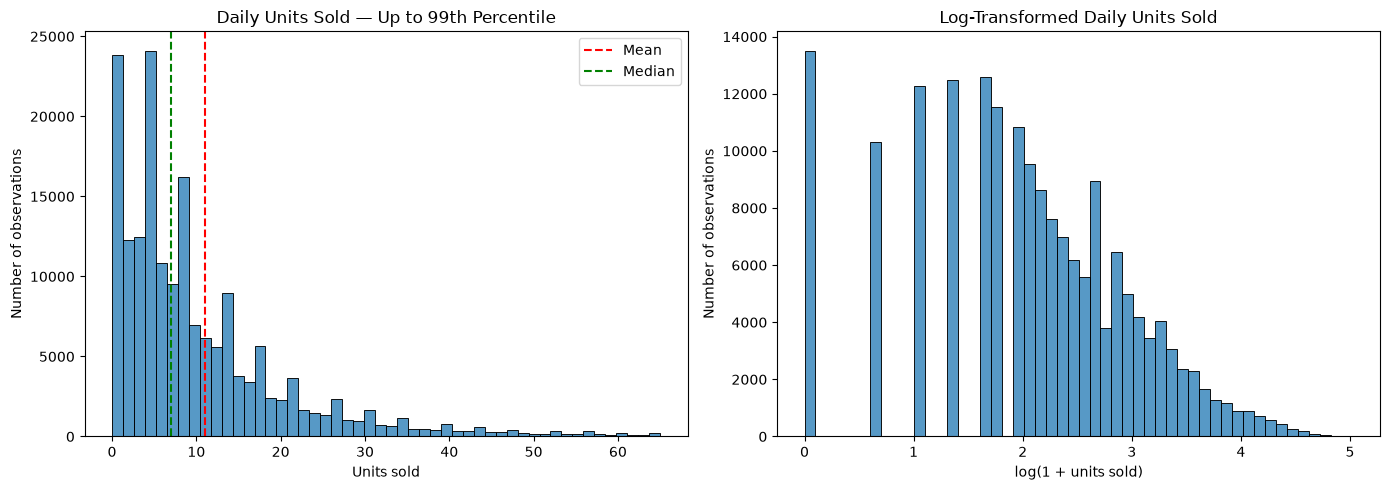

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sales_99th_percentile = (
    df["units_sold"].quantile(0.99)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
)

# Plot 1: Original scale, zoomed to the 99th percentile
sales_below_99th = df.loc[
    df["units_sold"] <= sales_99th_percentile,
    "units_sold",
]

sns.histplot(
    sales_below_99th,
    bins=50,
    ax=axes[0],
)

axes[0].axvline(
    df["units_sold"].mean(),
    color="red",
    linestyle="--",
    label="Mean",
)

axes[0].axvline(
    df["units_sold"].median(),
    color="green",
    linestyle="--",
    label="Median",
)

axes[0].set_title(
    "Daily Units Sold — Up to 99th Percentile"
)
axes[0].set_xlabel("Units sold")
axes[0].set_ylabel("Number of observations")
axes[0].legend()

# Plot 2: Log-transformed scale using all observations
log_sales = np.log1p(df["units_sold"])

sns.histplot(
    log_sales,
    bins=50,
    ax=axes[1],
)

axes[1].set_title(
    "Log-Transformed Daily Units Sold"
)
axes[1].set_xlabel("log(1 + units sold)")
axes[1].set_ylabel("Number of observations")

plt.tight_layout()
plt.show()

In [32]:
sales_skewness = df["units_sold"].skew()

print(
    "Sales distribution skewness:",
    round(sales_skewness, 3),
)

Sales distribution skewness: 2.838


#### Distribution-Shape Finding

The daily unit-sales distribution is strongly right-skewed, with a skewness value of 2.838.

Most observations are concentrated at lower sales quantities, while a smaller number of high-demand observations create a long right tail. The mean of approximately 11 units is therefore higher than the median of 7 units.

The logarithmic visualisation makes the tail easier to inspect but does not change the original dataset. The separated bars are expected because unit sales are discrete integer counts.

High-sales observations will not automatically be removed as outliers. They may represent genuine demand related to particular products, stores, dates, price changes or calendar events.

Because large forecast errors may occur in the right tail, both MAE and RMSE should be reported during model evaluation.

### 3.4 Investigating High-Demand Observations

The 99th percentile is approximately 65 units. Observations near or above this threshold form the high-demand tail.

These records are not automatically considered errors. We inspect them to determine whether they:

- Belong mainly to a small number of products.
- Are concentrated in one store or category.
- Occur repeatedly rather than as isolated events.
- Represent a meaningful share of total sales.

This investigation helps determine whether the forecasting model needs to learn recurring high-demand behaviour.

In [33]:
high_demand_threshold = (
    df["units_sold"].quantile(0.99)
)

high_demand_rows = (
    df.loc[
        df["units_sold"]
        >= high_demand_threshold
    ]
    .sort_values(
        "units_sold",
        ascending=False,
    )
    .copy()
)

high_demand_row_percentage = (
    len(high_demand_rows)
    / len(df)
    * 100
)

high_demand_sales_share = (
    high_demand_rows["units_sold"].sum()
    / df["units_sold"].sum()
    * 100
)

print(
    "99th-percentile threshold:",
    high_demand_threshold,
)

print(
    "High-demand observations:",
    f"{len(high_demand_rows):,}",
)

print(
    "Percentage of observations:",
    f"{high_demand_row_percentage:.2f}%",
)

print(
    "Share of total units sold:",
    f"{high_demand_sales_share:.2f}%",
)

display(
    high_demand_rows[
        [
            "date",
            "store_id",
            "product_id",
            "category_id",
            "units_sold",
            "sell_price",
        ]
    ].head(10)
)

99th-percentile threshold: 65.0
High-demand observations: 1,869
Percentage of observations: 1.04%
Share of total units sold: 7.52%


,date,store_id,product_id,category_id,units_sold,sell_price
9155908,2011-11-25,CA_3,FOODS_3_586,FOODS,151,1.48
28815526,2013-08-31,CA_1,FOODS_3_252,FOODS,147,1.48
50591818,2015-08-15,CA_3,FOODS_3_586,FOODS,142,1.68
21138478,2012-12-22,CA_3,FOODS_3_586,FOODS,140,1.58
50591484,2015-08-15,CA_3,FOODS_3_252,FOODS,138,1.58
38853168,2014-07-26,CA_3,FOODS_3_586,FOODS,137,1.58
9149810,2011-11-25,CA_1,FOODS_3_586,FOODS,133,1.48
39737378,2014-08-24,CA_3,FOODS_3_586,FOODS,130,1.68
39523948,2014-08-17,CA_3,FOODS_3_586,FOODS,128,1.68
27053538,2013-07-04,CA_3,FOODS_3_586,FOODS,124,1.58


#### High-Demand Tail Finding

The 99th-percentile threshold is 65 units. A total of 1,869 observations, representing 1.04% of the development dataset, recorded at least 65 units sold.

Although these observations represent only 1.04% of rows, they contribute 7.52% of total units sold. Consequently, accurate forecasting of the high-demand tail is important for inventory planning and stockout prevention.

The ten largest observations are all from the Foods category and are concentrated primarily in products `FOODS_3_586` and `FOODS_3_252`. Product `FOODS_3_586` records high demand repeatedly across different years and stores.

Some high-demand dates affect the same product across multiple stores or multiple products within the same store. This suggests that at least some high-demand observations may represent systematic calendar, seasonal or store-level effects rather than random data errors.

These observations will be retained. Their relationship with store, product, weekday, price and calendar events will be investigated before drawing causal conclusions.

In [34]:
high_demand_by_product = (
    high_demand_rows
    .groupby(
        [
            "store_id",
            "product_id",
            "category_id",
        ]
    )
    .agg(
        high_demand_days=("date", "count"),
        total_units_in_tail=("units_sold", "sum"),
        maximum_daily_sales=("units_sold", "max"),
    )
    .reset_index()
)

high_demand_by_product[
    "percentage_of_tail_days"
] = (
    high_demand_by_product["high_demand_days"]
    / len(high_demand_rows)
    * 100
).round(2)

high_demand_by_product[
    "percentage_of_tail_units"
] = (
    high_demand_by_product["total_units_in_tail"]
    / high_demand_rows["units_sold"].sum()
    * 100
).round(2)

high_demand_by_product = (
    high_demand_by_product
    .sort_values(
        "high_demand_days",
        ascending=False,
    )
)

display(high_demand_by_product.head(10))

,store_id,product_id,category_id,high_demand_days,total_units_in_tail,maximum_daily_sales,percentage_of_tail_days,percentage_of_tail_units
11,CA_3,FOODS_3_586,FOODS,1136,92490,151,60.78,62.17
3,CA_1,FOODS_3_586,FOODS,252,19211,133,13.48,12.91
2,CA_1,FOODS_3_252,FOODS,190,14947,147,10.17,10.05
9,CA_3,FOODS_3_252,FOODS,175,13362,138,9.36,8.98
5,CA_1,FOODS_3_714,FOODS,40,2921,93,2.14,1.96
18,CA_3,HOUSEHOLD_1_118,HOUSEHOLD,17,1314,115,0.91,0.88
14,CA_3,FOODS_3_714,FOODS,9,636,84,0.48,0.43
17,CA_3,HOBBIES_1_254,HOBBIES,9,719,102,0.48,0.48
13,CA_3,FOODS_3_702,FOODS,8,627,98,0.43,0.42
4,CA_1,FOODS_3_702,FOODS,6,521,119,0.32,0.35


#### Concentration of High-Demand Observations

The high-demand tail is highly concentrated rather than broadly distributed across the development subset.

Four product-store series—representing products `FOODS_3_586` and `FOODS_3_252` across stores CA_1 and CA_3—account for 93.79% of high-demand days and 94.11% of units sold within the high-demand tail.

Product `FOODS_3_586` alone accounts for 74.26% of high-demand days and 75.08% of tail units across the two stores.

At store CA_3, `FOODS_3_586` exceeded the dataset-wide threshold of 65 units on 1,136 out of 1,913 days, or approximately 59.38% of its observed days. Therefore, 65 units is not an unusual value for this particular series, even though it represents the 99th percentile across the complete development subset.

This demonstrates that a global demand threshold should not be interpreted as a product-level anomaly threshold. Products operate at different sales scales, so product-store-specific distributions must also be examined.

## 4. Product-Store Demand Profiles

### 4.1 Summary by Product-Store Series

The overall sales distribution combines products with very different demand levels.

A daily sale of 65 units may be normal for one product but extremely unusual for another. Therefore, we summarise each product-store series separately.

For every series, we calculate:

- Total units sold.
- Average daily sales.
- Median daily sales.
- Sales variability.
- Zero-sales days.
- Zero-sales percentage.
- Maximum daily sales.

These measurements help us distinguish high-volume, low-volume, stable and intermittent products.

In [35]:
series_summary = (
    df.groupby(
        [
            "store_id",
            "product_id",
            "category_id",
        ]
    )
    .agg(
        total_units_sold=("units_sold", "sum"),
        mean_daily_sales=("units_sold", "mean"),
        median_daily_sales=("units_sold", "median"),
        standard_deviation=("units_sold", "std"),
        zero_sales_days=(
            "units_sold",
            lambda values: (values == 0).sum(),
        ),
        maximum_daily_sales=("units_sold", "max"),
        observed_days=("date", "nunique"),
    )
    .reset_index()
)

series_summary["zero_sales_percentage"] = (
    series_summary["zero_sales_days"]
    / series_summary["observed_days"]
    * 100
).round(2)

series_summary["coefficient_of_variation"] = (
    series_summary["standard_deviation"]
    / series_summary["mean_daily_sales"]
).round(2)

In [36]:

highest_volume_series = (
    series_summary
    .sort_values(
        "mean_daily_sales",
        ascending=False,
    )
    .head(10)
)

display(highest_volume_series)

,store_id,product_id,category_id,total_units_sold,mean_daily_sales,median_daily_sales,standard_deviation,zero_sales_days,maximum_daily_sales,observed_days,zero_sales_percentage,coefficient_of_variation
70,CA_3,FOODS_3_586,FOODS,134386,70.248824,69.0,17.782236,5,151,1913,0.26,0.25
23,CA_1,FOODS_3_586,FOODS,87691,45.839519,43.0,16.400641,7,133,1913,0.37,0.36
60,CA_3,FOODS_3_252,FOODS,81456,42.580240,40.0,15.958332,6,138,1913,0.31,0.37
13,CA_1,FOODS_3_252,FOODS,74971,39.190277,35.0,18.723639,6,147,1913,0.31,0.48
69,CA_3,FOODS_3_555,FOODS,59092,30.889702,30.0,9.523801,4,76,1913,0.21,0.31
28,CA_1,FOODS_3_714,FOODS,54080,28.269733,25.0,14.504559,7,93,1913,0.37,0.51
75,CA_3,FOODS_3_714,FOODS,51893,27.126503,26.0,11.140398,8,84,1913,0.42,0.41
83,CA_3,HOUSEHOLD_1_118,HOUSEHOLD,43351,22.661265,22.0,13.058696,118,115,1913,6.17,0.58
51,CA_3,FOODS_2_197,FOODS,43148,22.555149,21.0,12.837218,88,74,1913,4.60,0.57
72,CA_3,FOODS_3_694,FOODS,42459,22.194982,21.0,7.993730,6,66,1913,0.31,0.36


In [37]:
lowest_volume_series = (
    series_summary
    .sort_values(
        "mean_daily_sales",
        ascending=True,
    )
    .head(10)
)

display(lowest_volume_series)

,store_id,product_id,category_id,total_units_sold,mean_daily_sales,median_daily_sales,standard_deviation,zero_sales_days,maximum_daily_sales,observed_days,zero_sales_percentage,coefficient_of_variation
30,CA_1,HOBBIES_1_074,HOBBIES,3061,1.600105,1.0,1.855259,744,13,1913,38.89,1.16
41,CA_1,HOUSEHOLD_1_425,HOUSEHOLD,3185,1.664924,1.0,1.655506,555,17,1913,29.01,0.99
39,CA_1,HOUSEHOLD_1_319,HOUSEHOLD,3372,1.762676,2.0,1.587783,514,9,1913,26.87,0.90
44,CA_1,HOUSEHOLD_1_506,HOUSEHOLD,3408,1.781495,1.0,1.976412,636,14,1913,33.25,1.11
42,CA_1,HOUSEHOLD_1_434,HOUSEHOLD,4071,2.128071,2.0,2.022057,478,12,1913,24.99,0.95
43,CA_1,HOUSEHOLD_1_498,HOUSEHOLD,4345,2.271302,2.0,1.829871,331,11,1913,17.30,0.81
64,CA_3,FOODS_3_400,FOODS,4665,2.438578,2.0,2.304606,339,20,1913,17.72,0.95
45,CA_1,HOUSEHOLD_1_516,HOUSEHOLD,4709,2.461579,2.0,1.864027,262,11,1913,13.70,0.76
35,CA_1,HOUSEHOLD_1_072,HOUSEHOLD,4908,2.565604,2.0,1.876135,260,11,1913,13.59,0.73
57,CA_3,FOODS_3_217,FOODS,5460,2.854156,2.0,2.493748,258,22,1913,13.49,0.87


#### Product-Store Demand Profile Finding

Demand scale varies substantially across the 94 product-store series.

The highest-volume series, CA_3 × `FOODS_3_586`, records average daily sales of 70.25 units. The lowest-volume series, CA_1 × `HOBBIES_1_074`, records average daily sales of 1.60 units. Therefore, the highest-volume series sells approximately 44 times more per day than the lowest-volume series.

CA_3 × `FOODS_3_586` has a median of 69 units, a zero-sales rate of only 0.26%, and a coefficient of variation of 0.25. Its demand is high-volume and relatively stable. The dataset-wide high-demand threshold of 65 units is below this series' normal daily demand and should not be interpreted as an anomaly for this product.

In comparison, CA_1 × `HOBBIES_1_074` has a median of 1 unit, a zero-sales rate of 38.89%, and a coefficient of variation of 1.16. Its demand is low-volume and much more variable relative to its average.

The same product also behaves differently across stores. This supports using both product and store identifiers during modeling and evaluating performance separately across product-store series.

### 4.2 Product-Store Series with the Most Zero-Sales Days

The overall dataset contains only 7.51% zero-sales observations, but this aggregate percentage may hide individual products with much higher zero-sales rates.

We therefore rank product-store series by their zero-sales percentage.

This allows us to identify which series have regular demand and which may require special treatment for intermittent demand.

In [38]:
highest_zero_sales_series = (
    series_summary
    .sort_values(
        [
            "zero_sales_percentage",
            "coefficient_of_variation",
        ],
        ascending=False,
    )
    [
        [
            "store_id",
            "product_id",
            "category_id",
            "mean_daily_sales",
            "median_daily_sales",
            "zero_sales_days",
            "zero_sales_percentage",
            "coefficient_of_variation",
            "maximum_daily_sales",
        ]
    ]
    .head(15)
)

display(highest_zero_sales_series)

,store_id,product_id,category_id,mean_daily_sales,median_daily_sales,zero_sales_days,zero_sales_percentage,coefficient_of_variation,maximum_daily_sales
30,CA_1,HOBBIES_1_074,HOBBIES,1.600105,1.0,744,38.89,1.16,13
44,CA_1,HOUSEHOLD_1_506,HOUSEHOLD,1.781495,1.0,636,33.25,1.11,14
32,CA_1,HOBBIES_1_233,HOBBIES,3.307371,2.0,624,32.62,1.38,35
61,CA_3,FOODS_3_349,FOODS,4.056456,3.0,558,29.17,1.07,21
41,CA_1,HOUSEHOLD_1_425,HOUSEHOLD,1.664924,1.0,555,29.01,0.99,17
31,CA_1,HOBBIES_1_209,HOBBIES,3.332985,2.0,542,28.33,1.29,43
39,CA_1,HOUSEHOLD_1_319,HOUSEHOLD,1.762676,2.0,514,26.87,0.90,9
42,CA_1,HOUSEHOLD_1_434,HOUSEHOLD,2.128071,2.0,478,24.99,0.95,12
46,CA_1,HOUSEHOLD_1_521,HOUSEHOLD,4.636174,4.0,369,19.29,0.93,34
37,CA_1,HOUSEHOLD_1_198,HOUSEHOLD,3.309984,3.0,365,19.08,0.89,18


#### Product-Level Zero-Sales Finding

The aggregate zero-sales rate of 7.51% hides meaningful differences between product-store series.

The highest zero-sales rate belongs to CA_1 × `HOBBIES_1_074`, which recorded zero sales on 744 of 1,913 days, or 38.89% of observations. It nevertheless recorded positive sales on 61.11% of days, meaning that the series is not dominated by zero demand.

Most series with high zero-sales percentages are Hobbies or Household products at store CA_1. Only two Foods series appear among the 15 highest-zero series.

The series with higher zero-sales rates also tend to have higher coefficients of variation. For example, CA_1 × `HOBBIES_1_233` has a zero-sales rate of 32.62% and a coefficient of variation of 1.38.

The selected development subset should not be described as universally highly intermittent. It is predominantly active, although some low-volume product-store series show moderate intermittency and high relative variability.

### 4.3 Demand-Pattern Classification Using ADI and CV²

Zero-sales percentage alone does not completely describe intermittent demand.

We use two complementary measurements:

1. Average Demand Interval (ADI), which measures how frequently positive demand occurs.
2. Squared coefficient of variation (CV²), which measures how variable the positive demand quantities are.

A commonly used demand-classification framework separates series into:

- Smooth: frequent and relatively stable demand.
- Erratic: frequent but highly variable demand.
- Intermittent: less frequent but relatively stable positive demand.
- Lumpy: less frequent and highly variable demand.

The thresholds are useful segmentation heuristics rather than absolute business rules.

In [39]:
demand_pattern_records = []

grouping_columns = [
    "store_id",
    "product_id",
    "category_id",
]

for group_key, group in df.groupby(
    grouping_columns,
    sort=False,
):
    store_id, product_id, category_id = group_key

    positive_demand = group.loc[
        group["units_sold"] > 0,
        "units_sold",
    ]

    total_periods = len(group)
    positive_periods = len(positive_demand)

    if positive_periods == 0:
        adi = np.inf
        cv_squared = np.nan
    else:
        adi = total_periods / positive_periods

        positive_mean = positive_demand.mean()
        positive_std = positive_demand.std()

        if positive_mean > 0:
            cv_squared = (
                positive_std / positive_mean
            ) ** 2
        else:
            cv_squared = np.nan

    demand_pattern_records.append({
        "store_id": store_id,
        "product_id": product_id,
        "category_id": category_id,
        "total_periods": total_periods,
        "positive_periods": positive_periods,
        "adi": adi,
        "cv_squared": cv_squared,
    })

demand_patterns = pd.DataFrame(
    demand_pattern_records
)

In [40]:
demand_pattern_records = []

grouping_columns = [
    "store_id",
    "product_id",
    "category_id",
]

for group_key, group in df.groupby(
    grouping_columns,
    sort=False,
):
    store_id, product_id, category_id = group_key

    positive_demand = group.loc[
        group["units_sold"] > 0,
        "units_sold",
    ]

    total_periods = len(group)
    positive_periods = len(positive_demand)

    if positive_periods == 0:
        adi = np.inf
        cv_squared = np.nan
    else:
        adi = total_periods / positive_periods

        positive_mean = positive_demand.mean()
        positive_std = positive_demand.std()

        if positive_mean > 0:
            cv_squared = (
                positive_std / positive_mean
            ) ** 2
        else:
            cv_squared = np.nan

    demand_pattern_records.append({
        "store_id": store_id,
        "product_id": product_id,
        "category_id": category_id,
        "total_periods": total_periods,
        "positive_periods": positive_periods,
        "adi": adi,
        "cv_squared": cv_squared,
    })

demand_patterns = pd.DataFrame(
    demand_pattern_records
)

In [41]:
demand_pattern_summary = (
    demand_patterns["demand_pattern"]
    .value_counts()
    .rename_axis("demand_pattern")
    .reset_index(name="number_of_series")
)

demand_pattern_summary["percentage"] = (
    demand_pattern_summary["number_of_series"]
    / len(demand_patterns)
    * 100
).round(2)

display(demand_pattern_summary)

KeyError: 'demand_pattern'

In [ ]:
demand_pattern_summary = (
    demand_patterns["demand_pattern"]
    .value_counts()
    .rename_axis("demand_pattern")
    .reset_index(name="number_of_series")
)

demand_pattern_summary["percentage"] = (
    demand_pattern_summary["number_of_series"]
    / len(demand_patterns)
    * 100
).round(2)

display(demand_pattern_summary)

,demand_pattern,number_of_series,percentage
0,Smooth,75,79.79
1,Erratic,11,11.70
2,Intermittent,5,5.32
3,Lumpy,3,3.19


### Demand-pattern findings

The ADI–CV² classification shows that the selected development dataset is
primarily composed of frequently selling products.

- **75 of 94 series (79.79%) are Smooth**: demand occurs frequently and
  positive demand quantities are relatively stable.
- **11 series (11.70%) are Erratic**: demand occurs frequently, but the
  quantities sold vary considerably.
- **5 series (5.32%) are Intermittent**: zero-demand intervals are less
  regular, although positive demand quantities are relatively stable.
- **3 series (3.19%) are Lumpy**: both the timing and size of demand are
  difficult to predict.

Overall, only **8.51%** of the product-store series are Intermittent or Lumpy.
Therefore, it would be inaccurate to describe the entire development subset
as highly intermittent. Most series have frequent demand, while a small group
may require specialized forecasting or inventory policies.

In [ ]:
difficult_series = (
    demand_patterns[
        demand_patterns["demand_pattern"].isin(
            ["Intermittent", "Lumpy"]
        )
    ]
    .sort_values(
        ["demand_pattern", "adi", "cv_squared"],
        ascending=[True, False, False],
    )
)

display(difficult_series)

,store_id,product_id,category_id,total_periods,positive_periods,adi,cv_squared,demand_pattern
0,CA_1,HOBBIES_1_074,HOBBIES,1913,1169,1.636441,0.432531,Intermittent
14,CA_1,HOUSEHOLD_1_506,HOUSEHOLD,1913,1277,1.498042,0.489094,Intermittent
11,CA_1,HOUSEHOLD_1_425,HOUSEHOLD,1913,1358,1.408689,0.411687,Intermittent
9,CA_1,HOUSEHOLD_1_319,HOUSEHOLD,1913,1399,1.367405,0.324623,Intermittent
12,CA_1,HOUSEHOLD_1_434,HOUSEHOLD,1913,1435,1.333101,0.427328,Intermittent
2,CA_1,HOBBIES_1_233,HOBBIES,1913,1289,1.484096,0.949068,Lumpy
78,CA_3,FOODS_3_349,FOODS,1913,1355,1.411808,0.525690,Lumpy
1,CA_1,HOBBIES_1_209,HOBBIES,1913,1371,1.395332,0.918157,Lumpy


### Demand-pattern classification

We classified each product-store time series using two measurements:

- **Average Demand Interval (ADI):** the average number of days between
  positive-demand observations. A larger ADI indicates less frequent demand.
- **Squared Coefficient of Variation (CV²):** measures how much the positive
  demand quantities vary relative to their average.

The classification shows that 75 of 94 series (79.79%) have smooth demand.
Only eight series are intermittent or lumpy, meaning that strong demand
intermittency is not a general characteristic of this development subset.

The intermittent and lumpy series are concentrated among several lower-volume
Hobbies and Household products in CA_1. These series may be more difficult to
forecast than the majority of regularly selling products.

These conclusions apply to the selected development subset and should not
automatically be generalized to the complete M5 dataset.

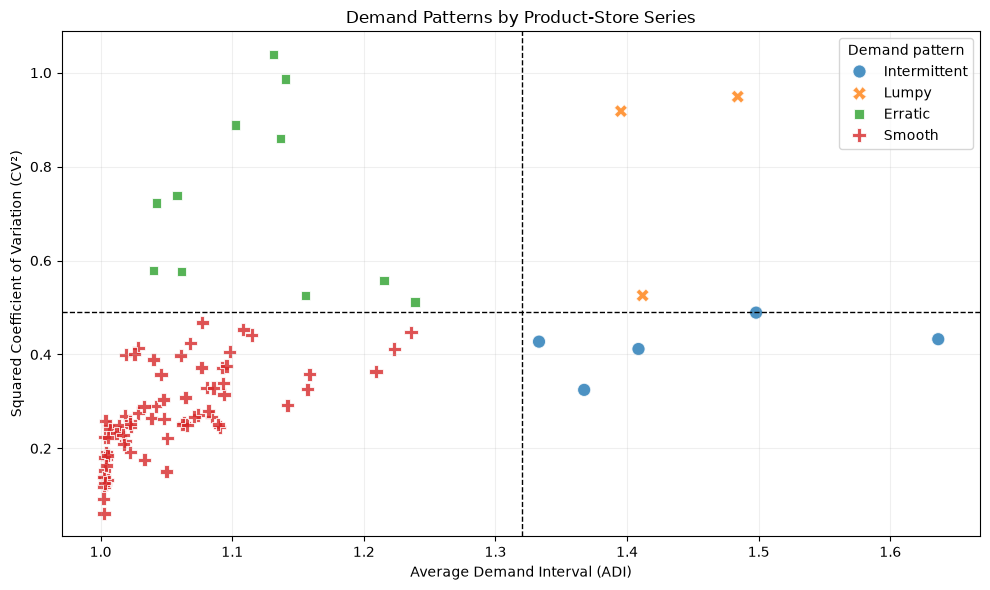

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=demand_patterns,
    x="adi",
    y="cv_squared",
    hue="demand_pattern",
    style="demand_pattern",
    s=90,
    alpha=0.8,
)

# Classification boundaries
plt.axvline(
    x=1.32,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    y=0.49,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.title("Demand Patterns by Product-Store Series")
plt.xlabel("Average Demand Interval (ADI)")
plt.ylabel("Squared Coefficient of Variation (CV²)")
plt.legend(title="Demand pattern")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation of demand patterns

Most product-store series are located in the smooth-demand region. Their ADI
values are close to 1, indicating that positive sales occur on most days, while
their CV² values suggest relatively stable positive-demand quantities.

A smaller group has erratic demand: sales occur frequently, but the quantities
vary considerably. Only five series are intermittent and three are lumpy.
Therefore, demand intermittency is present in certain products but is not the
dominant characteristic of this development subset.

The lumpy series are expected to be especially challenging because both the
timing and size of demand are variable. However, this classification alone does
not determine forecasting performance. Trend, seasonality, promotions and
price changes must still be investigated.

In [ ]:
pattern_order = [
    "Smooth",
    "Erratic",
    "Intermittent",
    "Lumpy",
]

pattern_by_store = pd.crosstab(
    demand_patterns["store_id"],
    demand_patterns["demand_pattern"],
).reindex(
    columns=pattern_order,
    fill_value=0,
)

pattern_percentage_by_store = (
    pattern_by_store
    .div(pattern_by_store.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

print("Number of series by store and demand pattern:")
display(pattern_by_store)

print("Percentage of series within each store:")
display(pattern_percentage_by_store)

Number of series by store and demand pattern:


demand_pattern,Smooth,Erratic,Intermittent,Lumpy
store_id,,,,
CA_1,37,3,5,2
CA_3,38,8,0,1


Percentage of series within each store:


demand_pattern,Smooth,Erratic,Intermittent,Lumpy
store_id,,,,
CA_1,78.72,6.38,10.64,4.26
CA_3,80.85,17.02,0.00,2.13


### Demand-pattern comparison by store

Smooth demand dominates both stores, accounting for approximately 79% of
series in CA_1 and 81% in CA_3. Therefore, neither store can be described as
predominantly intermittent.

The composition of the remaining series differs between stores. All five
intermittent series occur in CA_1, while CA_3 contains more erratic series.
This suggests that CA_1 has more products with irregular sales timing, whereas
CA_3 has more products that sell frequently but in variable quantities.

The overall proportion of non-smooth series is similar between the stores.
Consequently, neither store is clearly more difficult to forecast based only
on this classification. Forecast errors should later be evaluated separately
for each store.

In [ ]:
pattern_by_category = pd.crosstab(
    demand_patterns["category_id"],
    demand_patterns["demand_pattern"],
).reindex(
    columns=pattern_order,
    fill_value=0,
)

pattern_percentage_by_category = (
    pattern_by_category
    .div(pattern_by_category.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

print("Number of series by category and demand pattern:")
display(pattern_by_category)

print("Percentage of series within each category:")
display(pattern_percentage_by_category)

Number of series by category and demand pattern:


demand_pattern,Smooth,Erratic,Intermittent,Lumpy
category_id,,,,
FOODS,53,6,0,1
HOBBIES,3,4,1,2
HOUSEHOLD,19,1,4,0


Percentage of series within each category:


demand_pattern,Smooth,Erratic,Intermittent,Lumpy
category_id,,,,
FOODS,88.33,10.00,0.00,1.67
HOBBIES,30.00,40.00,10.00,20.00
HOUSEHOLD,79.17,4.17,16.67,0.00


### Demand-pattern comparison by category

Demand behaviour differs substantially between product categories. Foods has
the most regular demand: 88.33% of its product-store series are classified as
smooth, and none are intermittent.

Hobbies appears to be the most challenging category. Only 30% of its series
are smooth, while the remaining series are erratic, intermittent or lumpy.
This indicates variability in both the timing and quantity of demand. However,
the Hobbies result is based on only ten series and should not be generalized
to the complete M5 dataset.

Household demand is mostly smooth, although four series are intermittent.
These differences suggest that category information may be useful to the
forecasting model. Model performance should later be evaluated separately
for Foods, Hobbies and Household.

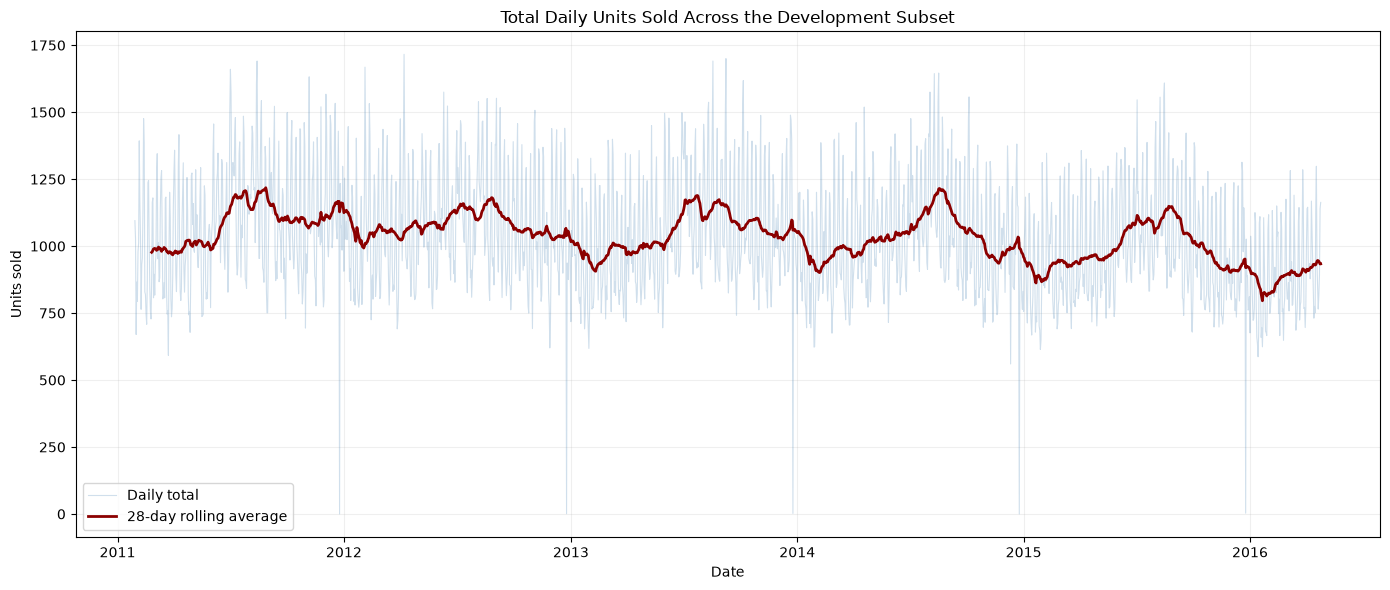

In [57]:
# Ensure that date behaves as a proper time variable.
df["date"] = pd.to_datetime(
    df["date"],
    errors="raise",
)

daily_total_sales = (
    df.groupby("date", as_index=False)
    .agg(total_units_sold=("units_sold", "sum"))
    .sort_values("date")
)

# A 28-day average reduces daily noise and reveals the broader movement.
daily_total_sales["rolling_mean_28"] = (
    daily_total_sales["total_units_sold"]
    .rolling(window=28, min_periods=28)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_total_sales["date"],
    daily_total_sales["total_units_sold"],
    color="steelblue",
    alpha=0.25,
    linewidth=0.8,
    label="Daily total",
)

plt.plot(
    daily_total_sales["date"],
    daily_total_sales["rolling_mean_28"],
    color="darkred",
    linewidth=2,
    label="28-day rolling average",
)

plt.title("Total Daily Units Sold Across the Development Subset")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Aggregate demand over time

Daily demand exhibits substantial short-term variation, while the 28-day
rolling average reveals broader recurring movements. There is no clear
continuous upward or downward trend across the full observation period.
Instead, the demand level moves through repeated periods of growth and decline.

Several extremely low-demand days appear near the end of each calendar year.
Because the series represents total demand across all selected products and
stores, these observations may indicate common store closures or calendar
events rather than ordinary product-level variation.

These dates must be investigated before deciding whether they are anomalies.
The aggregate plot can also be dominated by high-volume products, so later
analysis should compare trends by store and category.

In [ ]:
lowest_demand_days = (
    daily_total_sales
    .assign(
        day_of_week=daily_total_sales["date"].dt.day_name(),
        month_day=daily_total_sales["date"].dt.strftime("%m-%d"),
    )
    .nsmallest(
        15,
        "total_units_sold",
    )
)

display(
    lowest_demand_days[
        [
            "date",
            "day_of_week",
            "month_day",
            "total_units_sold",
        ]
    ]
)

number_of_zero_demand_days = (
    daily_total_sales["total_units_sold"] == 0
).sum()

print(
    "Number of days with zero demand across all series:",
    number_of_zero_demand_days,
)

,date,day_of_week,month_day,total_units_sold
330,2011-12-25,Sunday,12-25,0
1426,2014-12-25,Thursday,12-25,0
696,2012-12-25,Tuesday,12-25,1
1061,2013-12-25,Wednesday,12-25,2
1791,2015-12-25,Friday,12-25,3
1412,2014-12-11,Thursday,12-11,560
1811,2016-01-14,Thursday,01-14,587
54,2011-03-24,Thursday,03-24,592
1460,2015-01-28,Wednesday,01-28,614
732,2013-01-30,Wednesday,01-30,618


Number of days with zero demand across all series: 2


### Investigation of extremely low-demand dates

The five lowest-demand observations all occur on December 25. Total demand
across the development subset ranges from zero to only three units on these
dates, whereas the next-lowest daily total is 560 units.

This demonstrates that the sharp annual drops are associated with a recurring
calendar effect rather than missing dates. The observations should be retained
because they represent genuine business conditions, such as store closures or
restricted Christmas trading.

Calendar-event and holiday indicators will therefore be important forecasting
features. A lag-only model could substantially overpredict demand on these
exceptional dates.

In [ ]:
highest_demand_days = (
    daily_total_sales
    .assign(
        day_of_week=daily_total_sales["date"].dt.day_name(),
        month_day=daily_total_sales["date"].dt.strftime("%m-%d"),
    )
    .nlargest(
        15,
        "total_units_sold",
    )
)

display(
    highest_demand_days[
        [
            "date",
            "day_of_week",
            "month_day",
            "total_units_sold",
        ]
    ]
)

,date,day_of_week,month_day,total_units_sold
434,2012-04-07,Saturday,04-07,1716
953,2013-09-08,Sunday,09-08,1700
197,2011-08-14,Sunday,08-14,1691
932,2013-08-18,Sunday,08-18,1691
371,2012-02-04,Saturday,02-04,1668
154,2011-07-02,Saturday,07-02,1660
1296,2014-08-17,Sunday,08-17,1646
1289,2014-08-10,Sunday,08-10,1644
281,2011-11-06,Sunday,11-06,1632
981,2013-10-06,Sunday,10-06,1618


### Investigation of highest-demand dates

All 15 highest-demand dates occur on weekends. Eleven are Sundays and four
are Saturdays, providing strong initial evidence of weekly seasonality in
aggregate demand.

Seven of these dates also occur during August, suggesting that an annual or
summer-related pattern may interact with the weekend effect. However, the
highest-demand dates represent only a small selection of observations.
Average and median demand across every weekday must be compared before drawing
a broader conclusion.

These results suggest that day-of-week features will be important for the
forecasting model.

In [59]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_total_sales["day_of_week"] = (
    daily_total_sales["date"].dt.day_name()
)

weekday_summary = (
    daily_total_sales
    .groupby("day_of_week")
    .agg(
        number_of_days=("date", "count"),
        mean_daily_sales=("total_units_sold", "mean"),
        median_daily_sales=("total_units_sold", "median"),
        standard_deviation=("total_units_sold", "std"),
        minimum_daily_sales=("total_units_sold", "min"),
        maximum_daily_sales=("total_units_sold", "max"),
    )
    .reindex(weekday_order)
)

overall_daily_mean = daily_total_sales[
    "total_units_sold"
].mean()

weekday_summary["demand_index"] = (
    weekday_summary["mean_daily_sales"]
    / overall_daily_mean
    * 100
)

display(weekday_summary.round(2))

,number_of_days,mean_daily_sales,median_daily_sales,standard_deviation,minimum_daily_sales,maximum_daily_sales,demand_index
day_of_week,,,,,,,
Monday,273,993.61,987.0,141.39,670,1552,96.11
Tuesday,273,896.39,886.0,138.44,1,1325,86.71
Wednesday,273,879.99,872.0,137.68,2,1361,85.12
Thursday,273,895.14,884.0,144.35,0,1476,86.59
Friday,273,1021.89,1010.0,157.34,3,1546,98.85
Saturday,274,1264.07,1258.0,140.05,861,1716,122.27
Sunday,274,1283.85,1294.0,173.47,0,1700,124.19


In [ ]:
print("NEW OUTPUT: CATEGORY × WEEKDAY")

category_daily = (
    df.assign(date=pd.to_datetime(df["date"]))
    .groupby(
        ["date", "category_id"],
        as_index=False,
    )["units_sold"]
    .sum()
)

category_daily["day_of_week"] = (
    category_daily["date"].dt.day_name()
)

category_index_check = (
    category_daily
    .pivot_table(
        index="day_of_week",
        columns="category_id",
        values="units_sold",
        aggfunc="mean",
    )
)

category_average = (
    category_daily
    .groupby("category_id")["units_sold"]
    .mean()
)

category_index_check = (
    category_index_check
    .div(category_average, axis="columns")
    .mul(100)
    .reindex(weekday_order)
    .round(2)
)

print("Columns:", category_index_check.columns.tolist())
display(category_index_check)

NEW OUTPUT: CATEGORY × WEEKDAY
Columns: ['FOODS', 'HOBBIES', 'HOUSEHOLD']


category_id,FOODS,HOBBIES,HOUSEHOLD
day_of_week,,,
Monday,95.31,93.68,101.51
Tuesday,86.11,87.56,89.78
Wednesday,84.92,88.93,84.89
Thursday,86.83,91.08,83.61
Friday,99.87,99.30,92.84
Saturday,122.88,123.43,118.39
Sunday,123.89,115.87,128.80


### Weekly seasonality by category

The weekend increase is present across Foods, Hobbies and Household, confirming
that the aggregate weekly pattern is not produced only by high-volume Food
products.

Foods demand is approximately 23% above its category average on both Saturday
and Sunday. Hobbies reaches its highest demand on Saturday, while Household
has its strongest increase on Sunday.

Average weekend demand is approximately 30% to 37% higher than average
Monday-to-Friday demand across the three categories. Therefore, day-of-week
and weekend indicators are important candidate features. The differences
between categories also suggest that the relationship between category and
weekday should be captured by the forecasting model.

In [ ]:
daily_total_sales["month_number"] = (
    daily_total_sales["date"].dt.month
)

daily_total_sales["month_name"] = (
    daily_total_sales["date"].dt.month_name()
)

monthly_summary = (
    daily_total_sales
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        as_index=False,
    )
    .agg(
        number_of_days=("date", "count"),
        mean_daily_sales=("total_units_sold", "mean"),
        median_daily_sales=("total_units_sold", "median"),
        standard_deviation=("total_units_sold", "std"),
    )
    .sort_values("month_number")
)

monthly_summary["demand_index"] = (
    monthly_summary["mean_daily_sales"]
    / overall_daily_mean
    * 100
)

display(
    monthly_summary[
        [
            "month_name",
            "number_of_days",
            "mean_daily_sales",
            "median_daily_sales",
            "standard_deviation",
            "demand_index",
        ]
    ].round(2)
)

,month_name,number_of_days,mean_daily_sales,median_daily_sales,standard_deviation,demand_index
0,January,158,914.73,876.5,195.47,88.48
1,February,170,970.09,921.5,197.69,93.84
2,March,186,969.78,896.0,202.28,93.81
3,April,174,1005.54,943.5,196.82,97.27
4,May,155,1020.71,1010.0,173.93,98.73
5,June,150,1105.52,1061.0,180.04,106.94
6,July,155,1129.74,1100.0,190.88,109.28
7,August,155,1167.51,1156.0,225.16,112.93
8,September,150,1066.97,1005.0,211.98,103.21
9,October,155,1042.61,985.0,219.39,100.85


### Monthly demand seasonality

Aggregate demand displays a clear monthly pattern. Demand generally increases
from the beginning of the year until August and then declines during the
remaining months.

August has the highest demand index at 112.93, while January has the lowest at
88.48. Average August demand is approximately 27.6% higher than average January
demand. The high August median confirms that this result is not driven only by
a few extreme observations.

December has the highest standard deviation. This is partly explained by the
exceptionally low demand recorded on Christmas Day. Therefore, month features
alone will not capture all calendar effects, and specific holiday or event
features will also be required.

Because 2011 and 2016 are incomplete calendar years, the consistency of this
monthly pattern should be checked using the complete years from 2012 to 2015.

In [56]:
complete_year_data = (
    daily_total_sales
    .assign(year=daily_total_sales["date"].dt.year)
    .query("year >= 2012 and year <= 2015")
    .copy()
)

year_month_summary = (
    complete_year_data
    .groupby(
        [
            "year",
            "month_number",
        ],
        as_index=False,
    )
    .agg(
        mean_daily_sales=("total_units_sold", "mean")
    )
)

yearly_average = (
    complete_year_data
    .groupby("year")["total_units_sold"]
    .mean()
)

year_month_summary["monthly_index_within_year"] = (
    year_month_summary["mean_daily_sales"]
    / year_month_summary["year"].map(yearly_average)
    * 100
)

year_month_index = (
    year_month_summary
    .pivot(
        index="month_number",
        columns="year",
        values="monthly_index_within_year",
    )
    .reindex(range(1, 13))
)

month_labels = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

year_month_index.index = month_labels
year_month_index.index.name = "month"

display(year_month_index.round(2))

NameError: name 'daily_total_sales' is not defined

### Consistency of monthly seasonality

Monthly demand indices were calculated separately for the complete calendar
years from 2012 through 2015. The results confirm that the aggregate monthly
pattern is not driven by a single unusual year.

August is the highest-demand month in every complete year, with demand ranging
from approximately 8% to 16% above each year's daily average. January is
consistently below average, while June through September form a recurring
high-demand period.

The strength of the August effect increases in 2014 and 2015. This may suggest
a changing seasonal effect, although further modeling is required before it
can be interpreted as a persistent trend.

Month, week-of-year, weekday and event information should therefore be
considered as forecasting features.

In [ ]:
store_daily_sales = (
    df.groupby(
        [
            "date",
            "store_id",
        ],
        as_index=False,
    )
    .agg(
        total_units_sold=("units_sold", "sum")
    )
)

store_summary = (
    store_daily_sales
    .groupby(
        "store_id",
        as_index=False,
    )
    .agg(
        number_of_days=("date", "count"),
        total_units_sold=("total_units_sold", "sum"),
        mean_daily_sales=("total_units_sold", "mean"),
        median_daily_sales=("total_units_sold", "median"),
        standard_deviation=("total_units_sold", "std"),
        minimum_daily_sales=("total_units_sold", "min"),
        maximum_daily_sales=("total_units_sold", "max"),
    )
)

store_summary["share_of_total_units"] = (
    store_summary["total_units_sold"]
    / store_summary["total_units_sold"].sum()
    * 100
)

display(store_summary.round(2))

,store_id,number_of_days,total_units_sold,mean_daily_sales,median_daily_sales,standard_deviation,minimum_daily_sales,maximum_daily_sales,share_of_total_units
0,CA_1,1913,843548,440.96,417.0,117.12,0,822,42.65
1,CA_3,1913,1134136,592.86,583.0,112.50,0,976,57.35


### Store-level demand comparison

CA_3 is the higher-volume store, contributing 57.35% of all units sold in the
development subset. Its average daily demand is 592.86 units, approximately
34.4% higher than CA_1's average of 440.96 units.

The stores have similar absolute standard deviations, but CA_1 has greater
variability relative to its lower average demand. Its approximate coefficient
of variation is 0.27, compared with 0.19 for CA_3.

These differences suggest that store identity is an important forecasting
feature. Forecasting errors should also be reported separately for each store,
because one overall metric could hide poorer performance at CA_1 or CA_3.

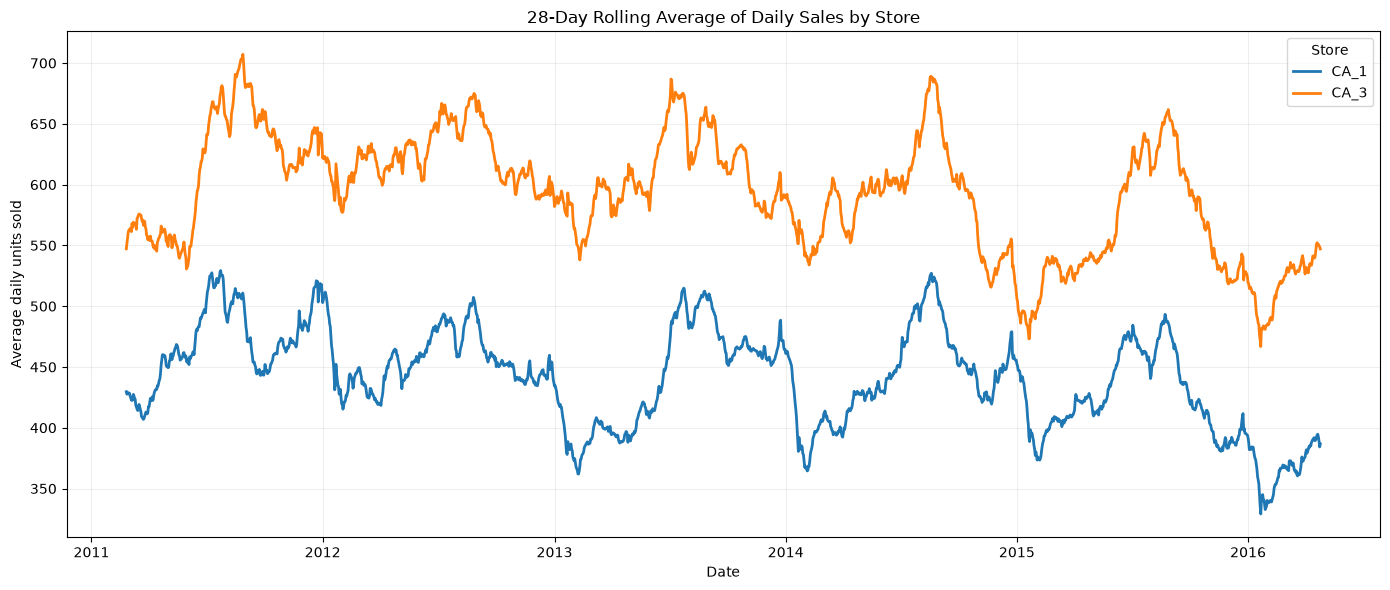

In [ ]:
store_daily_sales = (
    store_daily_sales
    .sort_values(
        [
            "store_id",
            "date",
        ]
    )
    .copy()
)

store_daily_sales["rolling_mean_28"] = (
    store_daily_sales
    .groupby("store_id")["total_units_sold"]
    .transform(
        lambda series: series.rolling(
            window=28,
            min_periods=28,
        ).mean()
    )
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=store_daily_sales,
    x="date",
    y="rolling_mean_28",
    hue="store_id",
    linewidth=2,
)

plt.title("28-Day Rolling Average of Daily Sales by Store")
plt.xlabel("Date")
plt.ylabel("Average daily units sold")
plt.legend(title="Store")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Store-level demand trends

CA_3 maintains a higher demand level than CA_1 throughout the observation
period. Nevertheless, the stores experience many peaks and declines at similar
times, suggesting that they are influenced by shared calendar and seasonal
effects.

The magnitude of these movements is not identical. Some increases and
decreases are stronger in one store, supporting the inclusion of store
identity in the forecasting model.

The apparent reduction toward early 2016 should be interpreted cautiously
because the dataset ends in April 2016 and does not contain a complete final
calendar year. The 28-day rolling average also suppresses weekly variation and
is intended only to reveal broader demand movements.

In [ ]:
daily_store_wide = (
    store_daily_sales
    .pivot(
        index="date",
        columns="store_id",
        values="total_units_sold",
    )
    .sort_index()
)

rolling_store_wide = (
    store_daily_sales
    .pivot(
        index="date",
        columns="store_id",
        values="rolling_mean_28",
    )
    .sort_index()
    .dropna()
)

daily_store_correlation = (
    daily_store_wide["CA_1"]
    .corr(daily_store_wide["CA_3"])
)

rolling_store_correlation = (
    rolling_store_wide["CA_1"]
    .corr(rolling_store_wide["CA_3"])
)

print(
    "Correlation of daily store sales:",
    round(daily_store_correlation, 3),
)

print(
    "Correlation of 28-day rolling averages:",
    round(rolling_store_correlation, 3),
)

Correlation of daily store sales: 0.801
Correlation of 28-day rolling averages: 0.78


### Correlation between store demand

Daily aggregate demand in CA_1 and CA_3 has a strong positive correlation of
0.801. This indicates that high- and low-demand days frequently occur in both
stores at similar times, likely because they share calendar effects such as
weekends, holidays and annual seasonality.

The correlation between their 28-day rolling averages is 0.780. Smoothing does
not increase the relationship, suggesting that the strong daily correlation
is partly associated with shared short-term calendar patterns. Differences in
the stores' medium-term movements remain present.

The correlation is descriptive and does not imply that demand in one store
causes demand changes in the other.

In [ ]:
store_daily_adjusted = (
    store_daily_sales
    .copy()
)

store_daily_adjusted["day_of_week"] = (
    store_daily_adjusted["date"].dt.day_name()
)

# Expected sales for each weekday within each store.
store_daily_adjusted["expected_weekday_sales"] = (
    store_daily_adjusted
    .groupby(
        [
            "store_id",
            "day_of_week",
        ]
    )["total_units_sold"]
    .transform("mean")
)

# Difference between actual demand and normal demand for that weekday.
store_daily_adjusted["weekday_adjusted_sales"] = (
    store_daily_adjusted["total_units_sold"]
    - store_daily_adjusted["expected_weekday_sales"]
)

weekday_adjusted_wide = (
    store_daily_adjusted
    .pivot(
        index="date",
        columns="store_id",
        values="weekday_adjusted_sales",
    )
)

weekday_adjusted_correlation = (
    weekday_adjusted_wide["CA_1"]
    .corr(weekday_adjusted_wide["CA_3"])
)

print(
    "Correlation after removing normal weekday effects:",
    round(weekday_adjusted_correlation, 3),
)

Correlation after removing normal weekday effects: 0.668


### Store correlation after weekday adjustment

After subtracting each store's typical demand for each weekday, the correlation
between CA_1 and CA_3 decreases from 0.801 to 0.668.

This confirms that shared weekly seasonality contributes to the original store
correlation. Nevertheless, the adjusted correlation remains moderately strong,
indicating that the stores also share broader demand movements beyond the
normal weekday pattern.

Possible common influences include annual seasonality, holidays, events and
promotions. These results support using both calendar features and store
identity in the forecasting model.

In [ ]:
lag_values = [
    1,
    7,
    14,
    28,
]

lag_correlation_records = []

for (
    store_id,
    product_id,
    category_id,
), series_data in df.groupby(
    [
        "store_id",
        "product_id",
        "category_id",
    ]
):
    series_data = series_data.sort_values("date")

    current_sales = series_data["units_sold"]

    for lag in lag_values:
        lagged_sales = current_sales.shift(lag)

        correlation = current_sales.corr(
            lagged_sales
        )

        lag_correlation_records.append(
            {
                "store_id": store_id,
                "product_id": product_id,
                "category_id": category_id,
                "lag": lag,
                "correlation": correlation,
            }
        )

lag_correlations = pd.DataFrame(
    lag_correlation_records
)

lag_correlation_summary = (
    lag_correlations
    .groupby(
        "lag",
        as_index=False,
    )
    .agg(
        number_of_series=("correlation", "count"),
        mean_correlation=("correlation", "mean"),
        median_correlation=("correlation", "median"),
        minimum_correlation=("correlation", "min"),
        maximum_correlation=("correlation", "max"),
        first_quartile=(
            "correlation",
            lambda values: values.quantile(0.25),
        ),
        third_quartile=(
            "correlation",
            lambda values: values.quantile(0.75),
        ),
    )
)

display(lag_correlation_summary.round(3))

,lag,number_of_series,mean_correlation,median_correlation,minimum_correlation,maximum_correlation,first_quartile,third_quartile
0,1,94,0.326,0.321,-0.013,0.786,0.193,0.415
1,7,94,0.311,0.301,0.012,0.684,0.211,0.398
2,14,94,0.279,0.271,0.012,0.656,0.181,0.346
3,28,94,0.273,0.263,0.019,0.637,0.186,0.362


### Lag-correlation analysis

Demand has a moderate positive relationship with its previous values. Lag 1
has the highest median correlation at 0.321, followed closely by lag 7 at
0.301. Correlations gradually decline for lags 14 and 28, although lag 28
remains positively related to demand across all 94 product-store series.

These results support using historical-demand features, but the moderate
correlation values show that lags alone will not fully explain demand.
Calendar, price, promotion, product and store information should also be
considered.

The forecasting horizon is 28 days. Therefore, lag availability must be
handled carefully. Actual lag-1, lag-7 and lag-14 values are not known for
every day of a 28-day future horizon. Using sales observed inside the holdout
to construct these features would cause target leakage. Lag 28 and older lags
are safe for an initial direct 28-day forecasting approach.

In [ ]:
lag_correlation_by_category = (
    lag_correlations
    .pivot_table(
        index="lag",
        columns="category_id",
        values="correlation",
        aggfunc="median",
    )
    .reindex(lag_values)
)

display(lag_correlation_by_category.round(3))

category_id,FOODS,HOBBIES,HOUSEHOLD
lag,,,
1,0.373,0.085,0.264
7,0.343,0.111,0.265
14,0.303,0.116,0.243
28,0.315,0.073,0.201


### Lag relationships by category

Lag correlations vary substantially between categories. Foods has the
strongest historical dependence at every evaluated lag, with median
correlations ranging from 0.303 to 0.373. Its lag-28 correlation is slightly
higher than its lag-14 correlation, suggesting a possible four-week pattern.

Household has moderate lag relationships that weaken as observations become
older. Hobbies has much weaker correlations, consistent with its higher
proportion of erratic and lumpy demand series.

These results suggest that lag-based forecasts may perform differently across
categories. Model evaluation should therefore report metrics separately for
Foods, Hobbies and Household. The model should also be capable of learning
interactions between category identity and historical-demand features.

In [ ]:
safe_lag_values = [
    28,
    35,
    42,
    49,
    56,
]

safe_lag_records = []

for (
    store_id,
    product_id,
    category_id,
), series_data in df.groupby(
    [
        "store_id",
        "product_id",
        "category_id",
    ]
):
    series_data = series_data.sort_values("date")
    current_sales = series_data["units_sold"]

    for lag in safe_lag_values:
        correlation = current_sales.corr(
            current_sales.shift(lag)
        )

        safe_lag_records.append(
            {
                "store_id": store_id,
                "product_id": product_id,
                "category_id": category_id,
                "lag": lag,
                "correlation": correlation,
            }
        )

safe_lag_correlations = pd.DataFrame(
    safe_lag_records
)

safe_lag_overall = (
    safe_lag_correlations
    .groupby("lag")["correlation"]
    .median()
    .rename("ALL_SERIES")
)

safe_lag_by_category = (
    safe_lag_correlations
    .pivot_table(
        index="lag",
        columns="category_id",
        values="correlation",
        aggfunc="median",
    )
)

safe_lag_summary = (
    safe_lag_overall
    .to_frame()
    .join(safe_lag_by_category)
    .reindex(safe_lag_values)
)

display(safe_lag_summary.round(3))

,ALL_SERIES,FOODS,HOBBIES,HOUSEHOLD
lag,,,,
28,0.263,0.315,0.073,0.201
35,0.243,0.286,0.093,0.191
42,0.208,0.264,0.080,0.171
49,0.189,0.248,0.082,0.160
56,0.215,0.254,0.060,0.154


### Forecast-safe lag relationships

For a 28-day batch forecast, lag 28 is the strongest historical-demand feature
that is available for every forecast day. Its median correlation is 0.263
across all series and 0.315 for Foods.

Lag correlations generally decline as observations become older. A small
increase appears at lag 56, particularly for Foods, which may indicate an
eight-week recurring relationship. This should be tested through time-based
validation rather than accepted from correlation alone.

Hobbies continues to show weak historical dependence. Consequently, lag-based
features may contribute less to forecasts for this category.

Candidate safe lags for the initial model are 28, 35, 42, 49 and 56 days, with
lag 28 expected to be the most informative.

In [42]:
safe_rolling_windows = [
    7,
    14,
    28,
]

safe_rolling_records = []

for (
    store_id,
    product_id,
    category_id,
), series_data in df.groupby(
    [
        "store_id",
        "product_id",
        "category_id",
    ]
):
    series_data = series_data.sort_values("date")
    current_sales = series_data["units_sold"]

    # Shift first so the rolling window never uses
    # information from inside the 28-day forecast horizon.
    safely_shifted_sales = current_sales.shift(28)

    for window in safe_rolling_windows:
        rolling_mean = (
            safely_shifted_sales
            .rolling(
                window=window,
                min_periods=window,
            )
            .mean()
        )

        correlation = current_sales.corr(
            rolling_mean
        )

        safe_rolling_records.append(
            {
                "store_id": store_id,
                "product_id": product_id,
                "category_id": category_id,
                "window": window,
                "correlation": correlation,
            }
        )

safe_rolling_correlations = pd.DataFrame(
    safe_rolling_records
)

safe_rolling_overall = (
    safe_rolling_correlations
    .groupby("window")["correlation"]
    .median()
    .rename("ALL_SERIES")
)

safe_rolling_by_category = (
    safe_rolling_correlations
    .pivot_table(
        index="window",
        columns="category_id",
        values="correlation",
        aggfunc="median",
    )
)

safe_rolling_summary = (
    safe_rolling_overall
    .to_frame()
    .join(safe_rolling_by_category)
    .reindex(safe_rolling_windows)
)

display(safe_rolling_summary.round(3))

,ALL_SERIES,FOODS,HOBBIES,HOUSEHOLD
window,,,,
7,0.261,0.293,0.124,0.215
14,0.269,0.295,0.135,0.232
28,0.253,0.296,0.166,0.238


### Forecast-safe rolling averages

Forecast-safe rolling averages were constructed by shifting demand by 28 days
before calculating each rolling window. This ensures that no sales from inside
the forecast horizon are used.

The 14-day rolling average has the strongest median correlation across all
series, although the differences between window sizes are small.

Foods benefits more from the exact lag-28 value, likely because an exact
four-week lag preserves the same weekday relationship. Hobbies and Household
benefit more from averaging multiple observations, which reduces noise and
stabilizes their demand estimates.

Both exact lag features and shifted rolling averages should be included as
candidates and compared through rolling-origin validation.

In [44]:
price_variation = (
    df.groupby(
        [
            "store_id",
            "product_id",
            "category_id",
        ],
        as_index=False,
    )
    .agg(
        available_price_days=("sell_price", "count"),
        unique_prices=("sell_price", "nunique"),
        minimum_price=("sell_price", "min"),
        median_price=("sell_price", "median"),
        maximum_price=("sell_price", "max"),
    )
)

price_variation["price_range_percentage"] = (
    (
        price_variation["maximum_price"]
        - price_variation["minimum_price"]
    )
    / price_variation["median_price"]
    * 100
)

price_variation_summary = (
    price_variation[
        [
            "unique_prices",
            "price_range_percentage",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

print("Overall price-variation summary:")
display(price_variation_summary.round(2))

print("Series with the largest relative price ranges:")
display(
    price_variation
    .sort_values(
        "price_range_percentage",
        ascending=False,
    )
    .head(10)
    .round(2)
)

Overall price-variation summary:


,unique_prices,price_range_percentage
count,94.00,94.00
mean,2.86,9.66
std,1.17,7.08
min,1.00,0.00
25%,2.00,5.71
50%,3.00,9.76
75%,3.00,12.66
90%,4.00,17.94
max,7.00,33.56


Series with the largest relative price ranges:


,store_id,product_id,category_id,available_price_days,unique_prices,minimum_price,median_price,maximum_price,price_range_percentage
57,CA_3,FOODS_3_217,FOODS,1913,3,1.98,2.98,2.98,33.56
64,CA_3,FOODS_3_400,FOODS,1913,3,1.99,2.98,2.98,33.22
89,CA_3,HOUSEHOLD_1_434,HOUSEHOLD,1913,4,2.74,3.97,3.97,30.98
3,CA_1,FOODS_2_181,FOODS,1913,3,1.97,2.00,2.38,20.50
7,CA_1,FOODS_2_371,FOODS,1913,3,1.97,2.00,2.38,20.50
44,CA_1,HOUSEHOLD_1_506,HOUSEHOLD,1913,6,3.17,3.47,3.88,20.46
91,CA_3,HOUSEHOLD_1_506,HOUSEHOLD,1913,6,3.17,3.47,3.88,20.46
26,CA_1,FOODS_3_697,FOODS,1913,4,2.98,2.98,3.58,20.13
73,CA_3,FOODS_3_697,FOODS,1913,4,2.98,2.98,3.58,20.13
14,CA_1,FOODS_3_349,FOODS,1913,4,1.38,1.58,1.68,18.99


### Price variation

Prices change relatively slowly in the development subset. The median
product-store series has three unique prices over the observation period, with
a median price range of approximately 9.76% relative to its typical price.

Several series have substantially larger ranges. The maximum observed relative
range is 33.56%, indicating that price changes may be meaningful for some
products. However, a low price should not automatically be described as a
promotion because it could represent an earlier permanent price level.

Raw prices are not directly comparable across different products. Price
features should therefore express the current price relative to the same
product's typical or previous price.

In [45]:
price_change_data = (
    df.sort_values(
        [
            "store_id",
            "product_id",
            "date",
        ]
    )
    .copy()
)

price_change_data["previous_price"] = (
    price_change_data
    .groupby(
        [
            "store_id",
            "product_id",
        ]
    )["sell_price"]
    .shift(1)
)

# Count only transitions where both prices are available.
# The first available price after missing values is not a change.
price_change_data["is_price_change"] = (
    price_change_data["sell_price"].notna()
    & price_change_data["previous_price"].notna()
    & (
        price_change_data["sell_price"]
        != price_change_data["previous_price"]
    )
)

price_change_counts = (
    price_change_data
    .groupby(
        [
            "store_id",
            "product_id",
            "category_id",
        ],
        as_index=False,
    )
    .agg(
        number_of_price_changes=(
            "is_price_change",
            "sum",
        )
    )
)

price_variation_with_changes = (
    price_variation
    .merge(
        price_change_counts,
        on=[
            "store_id",
            "product_id",
            "category_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

print("Distribution of price-change counts:")
display(
    price_variation_with_changes[
        "number_of_price_changes"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .round(2)
)

print("Series with the most price changes:")
display(
    price_variation_with_changes
    .sort_values(
        "number_of_price_changes",
        ascending=False,
    )
    .head(10)
    [
        [
            "store_id",
            "product_id",
            "category_id",
            "unique_prices",
            "number_of_price_changes",
            "minimum_price",
            "median_price",
            "maximum_price",
        ]
    ]
)

Distribution of price-change counts:


count    94.00
mean      2.20
std       1.62
min       0.00
25%       1.00
50%       2.00
75%       3.00
90%       5.00
max       9.00
Name: number_of_price_changes, dtype: float64

Series with the most price changes:


,store_id,product_id,category_id,unique_prices,number_of_price_changes,minimum_price,median_price,maximum_price
51,CA_3,FOODS_2_197,FOODS,7,9,2.98,3.28,3.43
4,CA_1,FOODS_2_197,FOODS,5,5,2.98,3.28,3.42
29,CA_1,FOODS_3_756,FOODS,4,5,2.48,2.68,2.88
80,CA_3,HOBBIES_1_254,HOBBIES,3,5,0.68,0.70,0.72
91,CA_3,HOUSEHOLD_1_506,HOUSEHOLD,6,5,3.17,3.47,3.88
20,CA_1,FOODS_3_473,FOODS,6,5,3.58,3.88,4.18
67,CA_3,FOODS_3_473,FOODS,6,5,3.58,3.88,4.18
76,CA_3,FOODS_3_756,FOODS,4,5,2.48,2.68,2.88
79,CA_3,HOBBIES_1_233,HOBBIES,3,5,0.68,0.70,0.72
44,CA_1,HOUSEHOLD_1_506,HOUSEHOLD,6,5,3.17,3.47,3.88


### Frequency of price changes

Prices are slow-moving across the development subset. The median product-store
series changes price only twice during the entire observation period, while
90% of series have no more than five transitions.

The number of unique prices and the number of transitions provide different
information. A series with more transitions than unique prices has returned
to a previously used price, which may indicate temporary discounts or price
reversals. However, this cannot be confirmed from price values alone.

Some products change price several times but within a very narrow price range.
Consequently, both transition frequency and percentage change magnitude must
be considered.

Full-history price statistics are used here only for descriptive EDA.
Forecasting features must be calculated using information available at the
forecast origin to prevent leakage.

In [46]:
price_change_rows = (
    price_change_data.loc[
        price_change_data["is_price_change"]
    ]
    .copy()
)

price_change_rows["change_direction"] = np.where(
    price_change_rows["sell_price"]
    > price_change_rows["previous_price"],
    "Increase",
    "Decrease",
)

price_change_rows["price_change_percentage"] = (
    (
        price_change_rows["sell_price"]
        - price_change_rows["previous_price"]
    )
    / price_change_rows["previous_price"]
    * 100
)

price_change_direction_summary = (
    price_change_rows
    .groupby(
        "change_direction",
        as_index=False,
    )
    .agg(
        number_of_changes=(
            "price_change_percentage",
            "count",
        ),
        mean_change_percentage=(
            "price_change_percentage",
            "mean",
        ),
        median_change_percentage=(
            "price_change_percentage",
            "median",
        ),
        minimum_change_percentage=(
            "price_change_percentage",
            "min",
        ),
        maximum_change_percentage=(
            "price_change_percentage",
            "max",
        ),
    )
)

price_change_direction_summary["percentage_of_changes"] = (
    price_change_direction_summary["number_of_changes"]
    / len(price_change_rows)
    * 100
)

display(price_change_direction_summary.round(2))

,change_direction,number_of_changes,mean_change_percentage,median_change_percentage,minimum_change_percentage,maximum_change_percentage,percentage_of_changes
0,Decrease,60,-7.86,-5.56,-33.56,-1.02,28.99
1,Increase,147,6.12,6.33,0.67,50.51,71.01


### Direction and magnitude of price changes

The development subset contains 207 price transitions. Approximately 71% are
increases and 29% are decreases. The median increase is 6.33%, while the median
decrease is 5.56% in absolute terms.

The largest decrease and increase may represent the same price reversal. A
33.56% reduction from $2.98 to $1.98 requires a 50.51% increase to return to
$2.98 because the percentage calculations use different denominators.

The dominance of increases may reflect gradual upward repricing, while some
decreases may represent temporary discounts. Price direction alone does not
establish a causal relationship with demand.

In [47]:
price_available = (
    df.loc[df["sell_price"].notna()]
    .sort_values(
        [
            "store_id",
            "product_id",
            "date",
        ]
    )
    .copy()
)

series_keys = [
    "store_id",
    "product_id",
    "category_id",
]

price_available["previous_available_price"] = (
    price_available
    .groupby(series_keys)["sell_price"]
    .shift(1)
)

price_available["new_price_spell"] = (
    price_available["previous_available_price"].isna()
    | (
        price_available["sell_price"]
        != price_available["previous_available_price"]
    )
)

price_available["price_spell_id"] = (
    price_available
    .groupby(series_keys)["new_price_spell"]
    .cumsum()
)

price_spells = (
    price_available
    .groupby(
        series_keys + ["price_spell_id"],
        as_index=False,
    )
    .agg(
        spell_price=("sell_price", "first"),
        spell_start=("date", "min"),
        spell_end=("date", "max"),
        spell_length_days=("date", "count"),
    )
)

price_spells["number_of_spells"] = (
    price_spells
    .groupby(series_keys)["price_spell_id"]
    .transform("max")
)

# Exclude the first and final spell because they may have started
# before or continued after the observed period.
completed_price_spells = price_spells.loc[
    (price_spells["price_spell_id"] > 1)
    & (
        price_spells["price_spell_id"]
        < price_spells["number_of_spells"]
    )
].copy()

print("Number of completed interior price spells:",
      len(completed_price_spells))

display(
    completed_price_spells["spell_length_days"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .round(2)
)

Number of completed interior price spells: 123


count     123.00
mean      490.91
std       435.17
min         7.00
25%       133.00
50%       385.00
75%       693.00
90%       957.60
max      1785.00
Name: spell_length_days, dtype: float64

### Duration of price spells

A price spell represents a continuous period during which a product-store
series maintains the same selling price. The analysis uses 123 completed
interior spells, excluding the first and final spell of each series because
their full durations may fall outside the observed period.

The median completed price spell lasts 385 days, while the mean is approximately
491 days. This indicates that most price changes are long-lasting rather than
frequent short-term promotions.

Nevertheless, the shortest spell lasts seven days, confirming that some
temporary weekly price changes may exist. Short spells should be investigated
to determine whether the price decreases and subsequently returns to its
previous level.

In [48]:
duration_labels = [
    "Short: 1-28 days",
    "Medium: 29-90 days",
    "Long: more than 90 days",
]

completed_price_spells["duration_group"] = pd.cut(
    completed_price_spells["spell_length_days"],
    bins=[
        0,
        28,
        90,
        np.inf,
    ],
    labels=duration_labels,
)

price_spell_duration_summary = (
    completed_price_spells["duration_group"]
    .value_counts(sort=False)
    .reindex(duration_labels)
    .rename("number_of_spells")
    .reset_index()
    .rename(
        columns={
            "duration_group": "duration_group",
        }
    )
)

price_spell_duration_summary["percentage"] = (
    price_spell_duration_summary["number_of_spells"]
    / len(completed_price_spells)
    * 100
)

display(price_spell_duration_summary.round(2))

,duration_group,number_of_spells,percentage
0,Short: 1-28 days,3,2.44
1,Medium: 29-90 days,14,11.38
2,Long: more than 90 days,106,86.18


### Price-spell duration groups

Most completed price spells are long-lasting. Approximately 86.18% remain
active for more than 90 days, while only three spells last 28 days or less.

This indicates that price changes in the development subset primarily represent
longer-term repricing rather than frequent temporary promotions. Price should
therefore be treated as a slow-moving forecasting feature.

The small number of short spells also limits the ability to estimate reliable
promotional price effects. Price-response conclusions must be interpreted
cautiously because long-term price changes may be confounded with trends,
inflation and product lifecycle effects.

In [49]:
price_spells_enriched = (
    price_spells
    .sort_values(
        series_keys + ["price_spell_id"]
    )
    .copy()
)

price_spells_enriched["previous_spell_price"] = (
    price_spells_enriched
    .groupby(series_keys)["spell_price"]
    .shift(1)
)

price_spells_enriched["next_spell_price"] = (
    price_spells_enriched
    .groupby(series_keys)["spell_price"]
    .shift(-1)
)

price_spells_enriched["change_from_previous_percentage"] = (
    (
        price_spells_enriched["spell_price"]
        - price_spells_enriched["previous_spell_price"]
    )
    / price_spells_enriched["previous_spell_price"]
    * 100
)

price_spells_enriched["lower_than_both_neighbors"] = (
    (
        price_spells_enriched["spell_price"]
        < price_spells_enriched["previous_spell_price"]
    )
    & (
        price_spells_enriched["spell_price"]
        < price_spells_enriched["next_spell_price"]
    )
)

price_spells_enriched["returned_to_previous_price"] = (
    np.isclose(
        price_spells_enriched["next_spell_price"],
        price_spells_enriched["previous_spell_price"],
        atol=0.001,
    )
)

short_price_spells = price_spells_enriched.loc[
    (
        price_spells_enriched["price_spell_id"] > 1
    )
    & (
        price_spells_enriched["price_spell_id"]
        < price_spells_enriched["number_of_spells"]
    )
    & (
        price_spells_enriched["spell_length_days"] <= 28
    )
]

display(
    short_price_spells[
        [
            "store_id",
            "product_id",
            "category_id",
            "spell_start",
            "spell_end",
            "spell_length_days",
            "previous_spell_price",
            "spell_price",
            "next_spell_price",
            "change_from_previous_percentage",
            "lower_than_both_neighbors",
            "returned_to_previous_price",
        ]
    ].round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_8208\2127850395.py:78: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,store_id,product_id,category_id,spell_start,spell_end,spell_length_days,previous_spell_price,spell_price,next_spell_price,change_from_previous_percentage,lower_than_both_neighbors,returned_to_previous_price
156,CA_3,FOODS_2_197,FOODS,2013-03-23,2013-04-19,28,3.28,3.00,3.28,-8.54,True,True
184,CA_3,FOODS_3_217,FOODS,2015-10-31,2015-11-06,7,2.98,1.98,2.98,-33.56,True,True
205,CA_3,FOODS_3_400,FOODS,2012-03-31,2012-04-06,7,2.98,1.99,2.98,-33.22,True,True


### Short temporary price spells

Only three completed price spells last 28 days or less. All three occur in
CA_3 Foods products and exhibit a discount-and-return pattern: the spell price
is lower than both neighbouring prices and the following price returns exactly
to the previous level.

Two spells are one-week reductions of approximately 33%, while one is a
four-week reduction of approximately 9%. These observations provide strong
retrospective evidence of temporary discount-like pricing.

The result is based on only three spells and should not be generalized to the
whole dataset. Features that use the following price or completed spell
duration would introduce future information unless planned future prices are
available at forecast time.

In [50]:
discount_response_records = []

for _, spell in short_price_spells.iterrows():
    store_id = spell["store_id"]
    product_id = spell["product_id"]

    spell_start = pd.to_datetime(
        spell["spell_start"]
    )
    spell_end = pd.to_datetime(
        spell["spell_end"]
    )
    spell_length = int(
        spell["spell_length_days"]
    )

    product_sales = df.loc[
        (df["store_id"] == store_id)
        & (df["product_id"] == product_id)
    ].copy()

    product_sales["date"] = pd.to_datetime(
        product_sales["date"]
    )

    before_start = (
        spell_start
        - pd.Timedelta(days=spell_length)
    )
    before_end = (
        spell_start
        - pd.Timedelta(days=1)
    )

    after_start = (
        spell_end
        + pd.Timedelta(days=1)
    )
    after_end = (
        spell_end
        + pd.Timedelta(days=spell_length)
    )

    before_sales = product_sales.loc[
        product_sales["date"].between(
            before_start,
            before_end,
        ),
        "units_sold",
    ]

    during_sales = product_sales.loc[
        product_sales["date"].between(
            spell_start,
            spell_end,
        ),
        "units_sold",
    ]

    after_sales = product_sales.loc[
        product_sales["date"].between(
            after_start,
            after_end,
        ),
        "units_sold",
    ]

    surrounding_baseline = pd.concat(
        [
            before_sales,
            after_sales,
        ]
    ).mean()

    discount_mean = during_sales.mean()

    sales_lift_percentage = (
        (
            discount_mean
            / surrounding_baseline
            - 1
        )
        * 100
        if surrounding_baseline > 0
        else np.nan
    )

    discount_response_records.append(
        {
            "store_id": store_id,
            "product_id": product_id,
            "spell_length_days": spell_length,
            "regular_price": spell[
                "previous_spell_price"
            ],
            "discount_price": spell[
                "spell_price"
            ],
            "before_mean_sales": before_sales.mean(),
            "discount_mean_sales": discount_mean,
            "after_mean_sales": after_sales.mean(),
            "surrounding_baseline": surrounding_baseline,
            "sales_lift_percentage": sales_lift_percentage,
        }
    )

discount_response = pd.DataFrame(
    discount_response_records
)

display(discount_response.round(2))

,store_id,product_id,spell_length_days,regular_price,discount_price,before_mean_sales,discount_mean_sales,after_mean_sales,surrounding_baseline,sales_lift_percentage
0,CA_3,FOODS_2_197,28,3.28,3.00,24.36,0.79,17.96,21.16,-96.29
1,CA_3,FOODS_3_217,7,2.98,1.98,1.71,0.86,1.29,1.50,-42.86
2,CA_3,FOODS_3_400,7,2.98,1.99,1.71,1.14,1.43,1.57,-27.27


### Observed sales during temporary discounts

None of the three identified temporary price reductions is associated with an
increase in observed sales relative to the immediately surrounding periods.

The strongest example is FOODS_2_197, where average recorded sales fall by
approximately 96% during a four-week price reduction. This pattern is unlikely
to represent a simple customer price response.

Possible explanations include reverse causality, stock availability problems,
clearance activity or another simultaneous event. The M5 dataset records sales
rather than unconstrained customer demand and does not provide actual inventory
levels. Consequently, stockout-related lost demand cannot be measured directly.

This small event comparison is descriptive and must not be interpreted as a
causal price-elasticity estimate.

In [51]:
cross_store_response_records = []

for _, spell in short_price_spells.iterrows():
    product_id = spell["product_id"]

    spell_start = pd.to_datetime(
        spell["spell_start"]
    )
    spell_end = pd.to_datetime(
        spell["spell_end"]
    )
    spell_length = int(
        spell["spell_length_days"]
    )

    before_start = (
        spell_start
        - pd.Timedelta(days=spell_length)
    )
    before_end = (
        spell_start
        - pd.Timedelta(days=1)
    )

    after_start = (
        spell_end
        + pd.Timedelta(days=1)
    )
    after_end = (
        spell_end
        + pd.Timedelta(days=spell_length)
    )

    for comparison_store in [
        "CA_1",
        "CA_3",
    ]:
        comparison_sales = df.loc[
            (df["store_id"] == comparison_store)
            & (df["product_id"] == product_id)
        ].copy()

        comparison_sales["date"] = pd.to_datetime(
            comparison_sales["date"]
        )

        before_mean = comparison_sales.loc[
            comparison_sales["date"].between(
                before_start,
                before_end,
            ),
            "units_sold",
        ].mean()

        during_mean = comparison_sales.loc[
            comparison_sales["date"].between(
                spell_start,
                spell_end,
            ),
            "units_sold",
        ].mean()

        after_mean = comparison_sales.loc[
            comparison_sales["date"].between(
                after_start,
                after_end,
            ),
            "units_sold",
        ].mean()

        surrounding_baseline = np.mean(
            [
                before_mean,
                after_mean,
            ]
        )

        lift_percentage = (
            (
                during_mean
                / surrounding_baseline
                - 1
            )
            * 100
            if surrounding_baseline > 0
            else np.nan
        )

        cross_store_response_records.append(
            {
                "product_id": product_id,
                "discount_store": spell["store_id"],
                "comparison_store": comparison_store,
                "spell_start": spell_start,
                "spell_length_days": spell_length,
                "before_mean_sales": before_mean,
                "during_mean_sales": during_mean,
                "after_mean_sales": after_mean,
                "surrounding_baseline": surrounding_baseline,
                "sales_change_percentage": lift_percentage,
            }
        )

cross_store_discount_comparison = pd.DataFrame(
    cross_store_response_records
)

display(
    cross_store_discount_comparison.round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_8208\3633424548.py:109: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  cross_store_discount_comparison.round(2)


,product_id,discount_store,comparison_store,spell_start,spell_length_days,before_mean_sales,during_mean_sales,after_mean_sales,surrounding_baseline,sales_change_percentage
0,FOODS_2_197,CA_3,CA_1,2013-03-23,28,22.57,0.00,21.14,21.86,-100.00
1,FOODS_2_197,CA_3,CA_3,2013-03-23,28,24.36,0.79,17.96,21.16,-96.29
2,FOODS_3_217,CA_3,CA_1,2015-10-31,7,4.14,3.71,3.14,3.64,1.96
3,FOODS_3_217,CA_3,CA_3,2015-10-31,7,1.71,0.86,1.29,1.50,-42.86
4,FOODS_3_400,CA_3,CA_1,2012-03-31,7,3.14,4.14,4.14,3.64,13.73
5,FOODS_3_400,CA_3,CA_3,2012-03-31,7,1.71,1.14,1.43,1.57,-27.27


### Cross-store comparison of temporary discounts

The 28-day FOODS_2_197 event coincides with a near-complete sales collapse in
both stores. CA_1 records zero average sales, while CA_3 falls by approximately
96%. Because the decline occurs across both stores, the CA_3 price reduction
is unlikely to be the main cause. A shared supply, availability or product-level
disruption is more plausible.

For FOODS_3_217 and FOODS_3_400, CA_1 demand remains stable or increases while
CA_3 demand falls. These patterns may reflect CA_3-specific conditions, but
each event contains only seven days and low sales volumes.

The analysis demonstrates why observational price changes should not be
interpreted as causal price elasticity. Recorded sales may be constrained by
unobserved inventory availability.

In [52]:
focus_product = "FOODS_2_197"

event_start = pd.Timestamp("2013-03-23")
event_end = pd.Timestamp("2013-04-19")
event_length = 28

before_start = (
    event_start
    - pd.Timedelta(days=event_length)
)

before_end = (
    event_start
    - pd.Timedelta(days=1)
)

after_start = (
    event_end
    + pd.Timedelta(days=1)
)

after_end = (
    event_end
    + pd.Timedelta(days=event_length)
)

focus_data = df.loc[
    (df["product_id"] == focus_product)
    & (
        pd.to_datetime(df["date"]).between(
            before_start,
            after_end,
        )
    )
].copy()

focus_data["date"] = pd.to_datetime(
    focus_data["date"]
)

focus_data["period"] = np.select(
    [
        focus_data["date"].between(
            before_start,
            before_end,
        ),
        focus_data["date"].between(
            event_start,
            event_end,
        ),
        focus_data["date"].between(
            after_start,
            after_end,
        ),
    ],
    [
        "Before",
        "During",
        "After",
    ],
    default="Outside",
)

period_order = [
    "Before",
    "During",
    "After",
]

focus_data["period"] = pd.Categorical(
    focus_data["period"],
    categories=period_order,
    ordered=True,
)

focus_period_summary = (
    focus_data
    .groupby(
        [
            "store_id",
            "period",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        number_of_days=("date", "count"),
        total_units_sold=("units_sold", "sum"),
        mean_daily_sales=("units_sold", "mean"),
        zero_sales_days=(
            "units_sold",
            lambda values: (values == 0).sum(),
        ),
        minimum_price=("sell_price", "min"),
        median_price=("sell_price", "median"),
        maximum_price=("sell_price", "max"),
    )
)

focus_period_summary["zero_sales_percentage"] = (
    focus_period_summary["zero_sales_days"]
    / focus_period_summary["number_of_days"]
    * 100
)

display(focus_period_summary.round(2))

,store_id,period,number_of_days,total_units_sold,mean_daily_sales,zero_sales_days,minimum_price,median_price,maximum_price,zero_sales_percentage
0,CA_1,Before,28,632,22.57,2,3.28,3.28,3.28,7.14
1,CA_1,During,28,0,0.00,28,3.28,3.28,3.28,100.00
2,CA_1,After,28,592,21.14,3,3.28,3.28,3.28,10.71
3,CA_3,Before,28,682,24.36,3,3.28,3.28,3.28,10.71
4,CA_3,During,28,22,0.79,15,3.00,3.00,3.00,53.57
5,CA_3,After,28,503,17.96,4,3.28,3.28,3.28,14.29


In [53]:
from pathlib import Path

calendar_candidates = list(
    Path(PROJECT_ROOT).rglob("calendar.csv")
)

if not calendar_candidates:
    raise FileNotFoundError(
        "calendar.csv was not found inside the project."
    )

calendar_path = calendar_candidates[0]

print("Calendar file:", calendar_path)

calendar = pd.read_csv(
    calendar_path
)

required_calendar_columns = [
    "d",
    "date",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "snap_CA",
]

missing_calendar_columns = (
    set(required_calendar_columns)
    - set(calendar.columns)
)

if missing_calendar_columns:
    raise ValueError(
        "Missing calendar columns: "
        f"{sorted(missing_calendar_columns)}"
    )

calendar["date"] = pd.to_datetime(
    calendar["date"],
    errors="raise",
)

calendar["day_num"] = pd.to_numeric(
    calendar["d"]
    .astype(str)
    .str.extract(r"(\d+)$")[0],
    errors="raise",
)

# Protect d_1914–d_1941.
calendar_eda = (
    calendar.loc[
        calendar["day_num"] <= 1913,
        required_calendar_columns + ["day_num"],
    ]
    .copy()
)

calendar_eda["has_event"] = (
    calendar_eda["event_name_1"].notna()
    | calendar_eda["event_name_2"].notna()
)

print("Calendar rows available for EDA:",
      len(calendar_eda))

print("Maximum calendar day used:",
      calendar_eda["day_num"].max())

print("Number of event days:",
      calendar_eda["has_event"].sum())

print("Number of SNAP-CA days:",
      calendar_eda["snap_CA"].sum())

Calendar file: c:\Users\USER\Desktop\agentic ai\ai_sales_forecasting\data\raw\calendar.csv
Calendar rows available for EDA: 1913
Maximum calendar day used: 1913
Number of event days: 154
Number of SNAP-CA days: 630


In [60]:
daily_calendar_sales = (
    daily_total_sales
    .merge(
        calendar_eda[
            [
                "date",
                "event_name_1",
                "event_type_1",
                "event_name_2",
                "event_type_2",
                "snap_CA",
                "has_event",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one",
    )
)

if daily_calendar_sales["snap_CA"].isna().any():
    raise ValueError(
        "Some daily sales dates did not match the calendar."
    )

event_summary = (
    daily_calendar_sales
    .assign(
        day_type=np.where(
            daily_calendar_sales["has_event"],
            "Event day",
            "No recorded event",
        )
    )
    .groupby(
        "day_type",
        as_index=False,
    )
    .agg(
        number_of_days=("date", "count"),
        mean_daily_sales=("total_units_sold", "mean"),
        median_daily_sales=("total_units_sold", "median"),
    )
)

event_summary["demand_index"] = (
    event_summary["mean_daily_sales"]
    / overall_daily_mean
    * 100
)

snap_summary = (
    daily_calendar_sales
    .assign(
        snap_status=np.where(
            daily_calendar_sales["snap_CA"] == 1,
            "SNAP-CA day",
            "Non-SNAP day",
        )
    )
    .groupby(
        "snap_status",
        as_index=False,
    )
    .agg(
        number_of_days=("date", "count"),
        mean_daily_sales=("total_units_sold", "mean"),
        median_daily_sales=("total_units_sold", "median"),
    )
)

snap_summary["demand_index"] = (
    snap_summary["mean_daily_sales"]
    / overall_daily_mean
    * 100
)

print("Event-day comparison:")
display(event_summary.round(2))

print("SNAP-day comparison:")
display(snap_summary.round(2))

Event-day comparison:


,day_type,number_of_days,mean_daily_sales,median_daily_sales,demand_index
0,Event day,154,996.95,1016.5,96.43
1,No recorded event,1759,1037.04,1003.0,100.31


SNAP-day comparison:


,snap_status,number_of_days,mean_daily_sales,median_daily_sales,demand_index
0,Non-SNAP day,1283,998.95,970.0,96.63
1,SNAP-CA day,630,1104.82,1075.0,106.87


## Final EDA Conclusions

### Data quality

The development subset contains 179,822 observations representing 94
product-store series across 1,913 consecutive days. No duplicate
date-store-product combinations, missing calendar dates, negative sales or
invalid available prices were detected.

The 966 missing prices occur only on zero-sales observations before the first
recorded positive sale. They are retained as missing rather than
forward-filled.

The protected period from d_1914 through d_1941 was excluded from all EDA.

### Demand characteristics

Daily sales are right-skewed, with a skewness of 2.838. However, high-demand
observations are concentrated among several naturally high-volume Food
products and should not automatically be treated as outliers.

Demand is mostly regular rather than highly intermittent:

- Smooth: 79.79%
- Erratic: 11.70%
- Intermittent: 5.32%
- Lumpy: 3.19%

Hobbies is the most challenging category, with only 30% of its selected series
classified as smooth. Foods has the most regular demand.

### Calendar seasonality

Demand has strong weekly seasonality. Average weekend demand is approximately
30% to 37% higher than Monday-to-Friday demand across all three categories.

Monthly seasonality is also consistent. August is the highest-demand month in
every complete year from 2012 through 2015, while January is consistently
below average.

Christmas produces near-zero aggregate demand and should be represented using
specific event features rather than removed as an outlier.

SNAP-CA days have approximately 10.6% higher mean demand than non-SNAP days.
This is an association rather than proof of causality, but snap_CA is a useful
future-known candidate feature.

### Store differences

CA_3 contributes 57.35% of total units and has approximately 34.4% higher
average daily demand than CA_1. The stores exhibit strong positive
co-movement, although their demand levels and some medium-term patterns differ.

Store identity should be included in the model, and forecast errors should be
reported separately by store.

### Historical-demand features

Lag relationships are moderate and differ by category. Foods has the strongest
historical dependence, while Hobbies has relatively weak lag correlations.

For the 28-day forecast horizon, safe candidate features include:

- lag_28
- lag_35
- lag_42
- lag_49
- lag_56
- rolling_mean_7_shifted_28
- rolling_mean_14_shifted_28
- rolling_mean_28_shifted_28

The shift must occur before calculating rolling statistics to prevent sales
inside the forecast horizon from leaking into the features.

### Price characteristics

Prices are slow-moving. The median product-store series has three unique prices
and only two price transitions across the observation period.

Approximately 86% of completed price spells last more than 90 days. Only three
short temporary discount-like spells were identified, which is insufficient
for reliable causal price-elasticity estimation.

Future prices may only be used when they are genuinely known at forecast time.
Full-history price statistics must not be used to build training features.

### Dataset limitations

The M5 dataset records observed sales rather than unconstrained customer
demand. Because inventory-on-hand and stockout data are unavailable, low sales
cannot always be distinguished from limited product availability.

Inventory levels will therefore need to be simulated or introduced as explicit
assumptions during the inventory-optimization phase.

These conclusions apply to the selected development subset and should not be
automatically generalized to the complete M5 dataset.